In [2]:
from pathlib import Path
import pandas as pd
import numpy as np
from IPython.display import display

# =========================================================
# 0. USTAWIENIA
# =========================================================
DATA_DIR = Path("data")   # <- zmień jeśli trzeba
OUT_DIR = DATA_DIR / "interim"
OUT_DIR.mkdir(parents=True, exist_ok=True)

# Tylko pliki, które bierzemy do rdzenia pipeline'u
CORE_FILES = {
    "MTeams": "MTeams.csv",
    "WTeams": "WTeams.csv",
    "MSeasons": "MSeasons.csv",
    "WSeasons": "WSeasons.csv",
    "MTeamConferences": "MTeamConferences.csv",
    "WTeamConferences": "WTeamConferences.csv",
    "MConferenceTourneyGames": "MConferenceTourneyGames.csv",
    "WConferenceTourneyGames": "WConferenceTourneyGames.csv",
    "MNCAATourneySeeds": "MNCAATourneySeeds.csv",
    "WNCAATourneySeeds": "WNCAATourneySeeds.csv",
    "MRegularSeasonDetailedResults": "MRegularSeasonDetailedResults.csv",
    "WRegularSeasonDetailedResults": "WRegularSeasonDetailedResults.csv",
    "MNCAATourneyDetailedResults": "MNCAATourneyDetailedResults.csv",
    "WNCAATourneyDetailedResults": "WNCAATourneyDetailedResults.csv",
    "MMasseyOrdinals": "MMasseyOrdinals.csv",
    "SampleSubmissionStage2": "SampleSubmissionStage2.csv",
}

# Zakres, na którym chcemy pracować
SEASON_MIN = 2014
SEASON_MAX = 2026

# =========================================================
# 1. FUNKCJE POMOCNICZE
# =========================================================
def load_csv_checked(path: Path) -> pd.DataFrame:
    if not path.exists():
        raise FileNotFoundError(f"Brak pliku: {path}")
    return pd.read_csv(path)

def build_catalog(dfs: dict) -> pd.DataFrame:
    rows = []
    for key, df in dfs.items():
        rows.append({
            "table_name": key,
            "rows": len(df),
            "cols": len(df.columns),
            "columns": ", ".join(df.columns.tolist())
        })
    return pd.DataFrame(rows).sort_values("table_name").reset_index(drop=True)

def prep_teams(df: pd.DataFrame, sex: str) -> pd.DataFrame:
    out = df.copy()
    out["Sex"] = sex

    if "FirstD1Season" not in out.columns:
        out["FirstD1Season"] = pd.NA
    if "LastD1Season" not in out.columns:
        out["LastD1Season"] = pd.NA

    out = out[["Sex", "TeamID", "TeamName", "FirstD1Season", "LastD1Season"]].copy()
    out["TeamID"] = out["TeamID"].astype("int64")
    out["TeamName"] = out["TeamName"].astype("string")
    out["FirstD1Season"] = out["FirstD1Season"].astype("Int64")
    out["LastD1Season"] = out["LastD1Season"].astype("Int64")
    return out.sort_values(["Sex", "TeamID"]).reset_index(drop=True)

def prep_seasons(df: pd.DataFrame, sex: str) -> pd.DataFrame:
    out = df.copy()
    out["Sex"] = sex

    keep_cols = ["Sex", "Season", "DayZero"]
    for c in ["RegionW", "RegionX", "RegionY", "RegionZ"]:
        if c in out.columns:
            keep_cols.append(c)

    out = out[keep_cols].copy()
    out["Season"] = out["Season"].astype("int64")
    out["DayZero"] = out["DayZero"].astype("string")
    return out.sort_values(["Sex", "Season"]).reset_index(drop=True)

def prep_team_conferences(df: pd.DataFrame, sex: str) -> pd.DataFrame:
    out = df.copy()
    out["Sex"] = sex
    out = out[["Sex", "Season", "TeamID", "ConfAbbrev"]].copy()
    out["Season"] = out["Season"].astype("int64")
    out["TeamID"] = out["TeamID"].astype("int64")
    out["ConfAbbrev"] = out["ConfAbbrev"].astype("string")
    out = out.query("@SEASON_MIN <= Season <= @SEASON_MAX").reset_index(drop=True)
    return out.sort_values(["Sex", "Season", "TeamID"]).reset_index(drop=True)

def prep_seeds(df: pd.DataFrame, sex: str) -> pd.DataFrame:
    out = df.copy()
    out["Sex"] = sex
    out = out[["Sex", "Season", "Seed", "TeamID"]].copy()

    out["Season"] = out["Season"].astype("int64")
    out["TeamID"] = out["TeamID"].astype("int64")
    out["Seed"] = out["Seed"].astype("string")

    out["SeedRegion"] = out["Seed"].str[0]
    out["SeedNum"] = out["Seed"].str[1:3].astype("int64")
    out["SeedPlayInFlag"] = out["Seed"].str.len().eq(4).astype("int64")
    out["SeedPlayInSuffix"] = np.where(out["Seed"].str.len().eq(4), out["Seed"].str[3], "")

    out = out.query("@SEASON_MIN <= Season <= @SEASON_MAX").reset_index(drop=True)
    return out.sort_values(["Sex", "Season", "Seed", "TeamID"]).reset_index(drop=True)

def prep_conf_tourney(df: pd.DataFrame, sex: str):
    expected = ["Season", "ConfAbbrev", "DayNum", "WTeamID", "LTeamID"]
    missing = [c for c in expected if c not in df.columns]
    if missing:
        raise ValueError(f"Brakuje kolumn w conference tourney: {missing}")

    base = df[expected].copy()
    base["Sex"] = sex
    base["Season"] = base["Season"].astype("int64")
    base["ConfAbbrev"] = base["ConfAbbrev"].astype("string")
    base["DayNum"] = base["DayNum"].astype("int64")
    base["WTeamID"] = base["WTeamID"].astype("int64")
    base["LTeamID"] = base["LTeamID"].astype("int64")
    base = base.query("@SEASON_MIN <= Season <= @SEASON_MAX").copy()

    base = base.sort_values(["Season", "DayNum", "ConfAbbrev", "WTeamID", "LTeamID"]).reset_index(drop=True)
    base["GameRowID"] = np.arange(1, len(base) + 1)

    w_side = (
        base.rename(columns={"WTeamID": "TeamID", "LTeamID": "OppTeamID"})
        .assign(Result=1, Win=1, Loss=0)
    )

    l_side = (
        base.rename(columns={"LTeamID": "TeamID", "WTeamID": "OppTeamID"})
        .assign(Result=0, Win=0, Loss=1)
    )

    long_df = pd.concat([w_side, l_side], ignore_index=True)
    long_df["IsConfTourneyGame"] = 1

    long_df = long_df[
        [
            "Sex", "Season", "ConfAbbrev", "DayNum", "GameRowID",
            "TeamID", "OppTeamID", "Result", "Win", "Loss", "IsConfTourneyGame"
        ]
    ].sort_values(["Sex", "Season", "TeamID", "DayNum", "GameRowID"]).reset_index(drop=True)

    season_df = (
        long_df.groupby(["Sex", "Season", "TeamID"], as_index=False)
        .agg(
            ConfTourneyGames=("GameRowID", "count"),
            ConfTourneyWins=("Win", "sum"),
            ConfTourneyLosses=("Loss", "sum"),
            ConfTourneyLastDay=("DayNum", "max"),
            ConfTourneyConfsPlayed=("ConfAbbrev", "nunique")
        )
    )

    season_df["ConfTourneyWinPct"] = np.where(
        season_df["ConfTourneyGames"] > 0,
        season_df["ConfTourneyWins"] / season_df["ConfTourneyGames"],
        np.nan
    )

    season_df["ConfTourneyUndefeated"] = (season_df["ConfTourneyLosses"] == 0).astype("int64")
    season_df = season_df.sort_values(["Sex", "Season", "TeamID"]).reset_index(drop=True)

    return long_df, season_df

def prep_submission_pairs(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    parts = out["ID"].str.split("_", expand=True)

    out["Season"] = parts[0].astype("int64")
    out["TeamIDLow"] = parts[1].astype("int64")
    out["TeamIDHigh"] = parts[2].astype("int64")

    out = out[["ID", "Season", "TeamIDLow", "TeamIDHigh", "Pred"]].copy()
    out = out.sort_values(["Season", "TeamIDLow", "TeamIDHigh"]).reset_index(drop=True)
    return out

# =========================================================
# 2. WCZYTANIE PLIKW
# =========================================================
dfs = {}
for key, file_name in CORE_FILES.items():
    dfs[key] = load_csv_checked(DATA_DIR / file_name)

catalog = build_catalog(dfs)
catalog.to_csv(OUT_DIR / "catalog_core_files.csv", index=False)

print("=== KATALOG PLIKÓW RDZENIA ===")
display(catalog)

# =========================================================
# 3. MAŁE TABELKI WYMIARÓW / POMOCNICZE
# =========================================================
m_teams_dim = prep_teams(dfs["MTeams"], sex="M")
w_teams_dim = prep_teams(dfs["WTeams"], sex="W")

m_seasons_dim = prep_seasons(dfs["MSeasons"], sex="M")
w_seasons_dim = prep_seasons(dfs["WSeasons"], sex="W")

m_team_conferences_dim = prep_team_conferences(dfs["MTeamConferences"], sex="M")
w_team_conferences_dim = prep_team_conferences(dfs["WTeamConferences"], sex="W")

m_seeds_dim = prep_seeds(dfs["MNCAATourneySeeds"], sex="M")
w_seeds_dim = prep_seeds(dfs["WNCAATourneySeeds"], sex="W")

m_conf_tourney_team_game_long, m_conf_tourney_team_season = prep_conf_tourney(
    dfs["MConferenceTourneyGames"], sex="M"
)
w_conf_tourney_team_game_long, w_conf_tourney_team_season = prep_conf_tourney(
    dfs["WConferenceTourneyGames"], sex="W"
)

stage2_pairs = prep_submission_pairs(dfs["SampleSubmissionStage2"])

# =========================================================
# 4. LEKKIE FILTROWANIE DUŻYCH PLIKÓW DO NASZEGO OKNA
# =========================================================
m_reg_det = dfs["MRegularSeasonDetailedResults"].query("@SEASON_MIN <= Season <= @SEASON_MAX").copy()
w_reg_det = dfs["WRegularSeasonDetailedResults"].query("@SEASON_MIN <= Season <= @SEASON_MAX").copy()
m_ncaa_det = dfs["MNCAATourneyDetailedResults"].query("@SEASON_MIN <= Season <= @SEASON_MAX").copy()
w_ncaa_det = dfs["WNCAATourneyDetailedResults"].query("@SEASON_MIN <= Season <= @SEASON_MAX").copy()

m_massey = dfs["MMasseyOrdinals"].query("@SEASON_MIN <= Season <= @SEASON_MAX").copy()

# =========================================================
# 5. ZAPIS
# =========================================================
m_teams_dim.to_csv(OUT_DIR / "m_teams_dim.csv", index=False)
w_teams_dim.to_csv(OUT_DIR / "w_teams_dim.csv", index=False)

m_seasons_dim.to_csv(OUT_DIR / "m_seasons_dim.csv", index=False)
w_seasons_dim.to_csv(OUT_DIR / "w_seasons_dim.csv", index=False)

m_team_conferences_dim.to_csv(OUT_DIR / "m_team_conferences_dim.csv", index=False)
w_team_conferences_dim.to_csv(OUT_DIR / "w_team_conferences_dim.csv", index=False)

m_seeds_dim.to_csv(OUT_DIR / "m_seeds_dim.csv", index=False)
w_seeds_dim.to_csv(OUT_DIR / "w_seeds_dim.csv", index=False)

m_conf_tourney_team_game_long.to_csv(OUT_DIR / "m_conf_tourney_team_game_long.csv", index=False)
w_conf_tourney_team_game_long.to_csv(OUT_DIR / "w_conf_tourney_team_game_long.csv", index=False)

m_conf_tourney_team_season.to_csv(OUT_DIR / "m_conf_tourney_team_season.csv", index=False)
w_conf_tourney_team_season.to_csv(OUT_DIR / "w_conf_tourney_team_season.csv", index=False)

stage2_pairs.to_csv(OUT_DIR / "sample_submission_stage2_pairs.csv", index=False)

# Opcjonalnie zapis przefiltrowanych dużych tabel
m_reg_det.to_csv(OUT_DIR / "m_regular_season_detailed_2014_2026.csv", index=False)
w_reg_det.to_csv(OUT_DIR / "w_regular_season_detailed_2014_2026.csv", index=False)
m_ncaa_det.to_csv(OUT_DIR / "m_ncaa_tourney_detailed_2014_2026.csv", index=False)
w_ncaa_det.to_csv(OUT_DIR / "w_ncaa_tourney_detailed_2014_2026.csv", index=False)
m_massey.to_csv(OUT_DIR / "m_massey_2014_2026.csv", index=False)

# =========================================================
# 6. PODGLĄD
# =========================================================
print("\n=== TEAMS DIM (M) ===")
display(m_teams_dim.head())

print("\n=== TEAMS DIM (W) ===")
display(w_teams_dim.head())

print("\n=== SEEDS DIM (M) ===")
display(m_seeds_dim.head())

print("\n=== TEAM CONFERENCES (M) ===")
display(m_team_conferences_dim.head())

print("\n=== CONF TOURNEY TEAM-SEASON (M) ===")
display(m_conf_tourney_team_season.head())

print("\n=== STAGE2 PAIRS ===")
display(stage2_pairs.head())

print("\n=== DUŻE PLIKI PO FILTRZE ===")
summary_big = pd.DataFrame([
    {"table": "m_reg_det", "rows": len(m_reg_det), "cols": len(m_reg_det.columns)},
    {"table": "w_reg_det", "rows": len(w_reg_det), "cols": len(w_reg_det.columns)},
    {"table": "m_ncaa_det", "rows": len(m_ncaa_det), "cols": len(m_ncaa_det.columns)},
    {"table": "w_ncaa_det", "rows": len(w_ncaa_det), "cols": len(w_ncaa_det.columns)},
    {"table": "m_massey", "rows": len(m_massey), "cols": len(m_massey.columns)},
])
display(summary_big)

print(f"\nGotowe. Pliki pośrednie zapisane do: {OUT_DIR.resolve()}")

=== KATALOG PLIKÓW RDZENIA ===


,table_name,rows,cols,columns
0,MConferenceTourneyGames,6793,5,"Season, ConfAbbrev, DayNum, WTeamID, LTeamID"
1,MMasseyOrdinals,5819228,5,"Season, RankingDayNum, SystemName, TeamID, Ord..."
2,MNCAATourneyDetailedResults,1449,34,"Season, DayNum, WTeamID, WScore, LTeamID, LSco..."
3,MNCAATourneySeeds,2626,3,"Season, Seed, TeamID"
4,MRegularSeasonDetailedResults,124031,34,"Season, DayNum, WTeamID, WScore, LTeamID, LSco..."
5,MSeasons,42,6,"Season, DayZero, RegionW, RegionX, RegionY, Re..."
6,MTeamConferences,13753,3,"Season, TeamID, ConfAbbrev"
7,MTeams,381,4,"TeamID, TeamName, FirstD1Season, LastD1Season"
8,SampleSubmissionStage2,132133,2,"ID, Pred"
9,WConferenceTourneyGames,6481,5,"Season, ConfAbbrev, DayNum, WTeamID, LTeamID"



=== TEAMS DIM (M) ===


,Sex,TeamID,TeamName,FirstD1Season,LastD1Season
0,M,1101,Abilene Chr,2014,2026
1,M,1102,Air Force,1985,2026
2,M,1103,Akron,1985,2026
3,M,1104,Alabama,1985,2026
4,M,1105,Alabama A&M,2000,2026



=== TEAMS DIM (W) ===


...


=== STAGE2 PAIRS ===


,ID,Season,TeamIDLow,TeamIDHigh,Pred
0,2026_1101_1102,2026,1101,1102,0.5
1,2026_1101_1103,2026,1101,1103,0.5
2,2026_1101_1104,2026,1101,1104,0.5
3,2026_1101_1105,2026,1101,1105,0.5
4,2026_1101_1106,2026,1101,1106,0.5



=== DUŻE PLIKI PO FILTRZE ===


,table,rows,cols
0,m_reg_det,68875,34
1,w_reg_det,66418,34
2,m_ncaa_det,736,34
3,w_ncaa_det,709,34
4,m_massey,3799306,5



Gotowe. Pliki pośrednie zapisane do: C:\Users\66891\BALLER2\data\interim


In [3]:
from pathlib import Path
import pandas as pd
import numpy as np
from IPython.display import display

# =========================================================
# 0. USTAWIENIA
# =========================================================
DATA_DIR = Path("data")
OUT_DIR = DATA_DIR / "interim"
OUT_DIR.mkdir(parents=True, exist_ok=True)

SEASON_MIN = 2014
SEASON_MAX = 2026
FTA_WEIGHT = 0.475  # klasyczne przybliżenie possessions

# =========================================================
# 1. FUNKCJE POMOCNICZE
# =========================================================
def safe_div(num, den):
    num = pd.Series(num, dtype="float64")
    den = pd.Series(den, dtype="float64")
    out = num / den
    out = out.replace([np.inf, -np.inf], np.nan)
    return out

def loser_loc_from_wloc(wloc_series: pd.Series) -> pd.Series:
    return wloc_series.map({"H": "A", "A": "H", "N": "N"}).fillna("N")

def load_if_needed(var_name: str, fallback_path: Path):
    if var_name in globals():
        return globals()[var_name].copy()
    return pd.read_csv(fallback_path)

def regular_detailed_to_team_game_long(df: pd.DataFrame, sex: str, team_conf_df: pd.DataFrame) -> pd.DataFrame:
    base = df.copy()
    base = base.query("@SEASON_MIN <= Season <= @SEASON_MAX").copy()

    # identyfikator techniczny meczu
    base = base.sort_values(["Season", "DayNum", "WTeamID", "LTeamID"]).reset_index(drop=True)
    base["GameRowID"] = np.arange(1, len(base) + 1)

    # -------------------------
    # zwycięzca -> perspektywa team
    # -------------------------
    w_side = pd.DataFrame({
        "Sex": sex,
        "Season": base["Season"].astype("int64"),
        "DayNum": base["DayNum"].astype("int64"),
        "GameRowID": base["GameRowID"].astype("int64"),
        "TeamID": base["WTeamID"].astype("int64"),
        "OppTeamID": base["LTeamID"].astype("int64"),
        "TeamScore": base["WScore"].astype("int64"),
        "OppScore": base["LScore"].astype("int64"),
        "TeamLoc": base["WLoc"].astype("string"),
        "NumOT": base["NumOT"].astype("int64"),
        "Win": 1,
        "Loss": 0,
        "FGM": base["WFGM"].astype("int64"),
        "FGA": base["WFGA"].astype("int64"),
        "FGM3": base["WFGM3"].astype("int64"),
        "FGA3": base["WFGA3"].astype("int64"),
        "FTM": base["WFTM"].astype("int64"),
        "FTA": base["WFTA"].astype("int64"),
        "OR": base["WOR"].astype("int64"),
        "DR": base["WDR"].astype("int64"),
        "Ast": base["WAst"].astype("int64"),
        "TO": base["WTO"].astype("int64"),
        "Stl": base["WStl"].astype("int64"),
        "Blk": base["WBlk"].astype("int64"),
        "PF": base["WPF"].astype("int64"),
        "OppFGM": base["LFGM"].astype("int64"),
        "OppFGA": base["LFGA"].astype("int64"),
        "OppFGM3": base["LFGM3"].astype("int64"),
        "OppFGA3": base["LFGA3"].astype("int64"),
        "OppFTM": base["LFTM"].astype("int64"),
        "OppFTA": base["LFTA"].astype("int64"),
        "OppOR": base["LOR"].astype("int64"),
        "OppDR": base["LDR"].astype("int64"),
        "OppAst": base["LAst"].astype("int64"),
        "OppTO": base["LTO"].astype("int64"),
        "OppStl": base["LStl"].astype("int64"),
        "OppBlk": base["LBlk"].astype("int64"),
        "OppPF": base["LPF"].astype("int64"),
    })

    # -------------------------
    # przegrany -> perspektywa team
    # -------------------------
    l_side = pd.DataFrame({
        "Sex": sex,
        "Season": base["Season"].astype("int64"),
        "DayNum": base["DayNum"].astype("int64"),
        "GameRowID": base["GameRowID"].astype("int64"),
        "TeamID": base["LTeamID"].astype("int64"),
        "OppTeamID": base["WTeamID"].astype("int64"),
        "TeamScore": base["LScore"].astype("int64"),
        "OppScore": base["WScore"].astype("int64"),
        "TeamLoc": loser_loc_from_wloc(base["WLoc"]).astype("string"),
        "NumOT": base["NumOT"].astype("int64"),
        "Win": 0,
        "Loss": 1,
        "FGM": base["LFGM"].astype("int64"),
        "FGA": base["LFGA"].astype("int64"),
        "FGM3": base["LFGM3"].astype("int64"),
        "FGA3": base["LFGA3"].astype("int64"),
        "FTM": base["LFTM"].astype("int64"),
        "FTA": base["LFTA"].astype("int64"),
        "OR": base["LOR"].astype("int64"),
        "DR": base["LDR"].astype("int64"),
        "Ast": base["LAst"].astype("int64"),
        "TO": base["LTO"].astype("int64"),
        "Stl": base["LStl"].astype("int64"),
        "Blk": base["LBlk"].astype("int64"),
        "PF": base["LPF"].astype("int64"),
        "OppFGM": base["WFGM"].astype("int64"),
        "OppFGA": base["WFGA"].astype("int64"),
        "OppFGM3": base["WFGM3"].astype("int64"),
        "OppFGA3": base["WFGA3"].astype("int64"),
        "OppFTM": base["WFTM"].astype("int64"),
        "OppFTA": base["WFTA"].astype("int64"),
        "OppOR": base["WOR"].astype("int64"),
        "OppDR": base["WDR"].astype("int64"),
        "OppAst": base["WAst"].astype("int64"),
        "OppTO": base["WTO"].astype("int64"),
        "OppStl": base["WStl"].astype("int64"),
        "OppBlk": base["WBlk"].astype("int64"),
        "OppPF": base["WPF"].astype("int64"),
    })

    long_df = pd.concat([w_side, l_side], ignore_index=True)

    # -------------------------
    # cechy meczowe
    # -------------------------
    long_df["Margin"] = long_df["TeamScore"] - long_df["OppScore"]

    long_df["IsHome"] = long_df["TeamLoc"].eq("H").astype("int64")
    long_df["IsAway"] = long_df["TeamLoc"].eq("A").astype("int64")
    long_df["IsNeutral"] = long_df["TeamLoc"].eq("N").astype("int64")

    long_df["HomeWin"] = ((long_df["IsHome"] == 1) & (long_df["Win"] == 1)).astype("int64")
    long_df["AwayWin"] = ((long_df["IsAway"] == 1) & (long_df["Win"] == 1)).astype("int64")
    long_df["NeutralWin"] = ((long_df["IsNeutral"] == 1) & (long_df["Win"] == 1)).astype("int64")

    # possessions
    team_poss = long_df["FGA"] - long_df["OR"] + long_df["TO"] + FTA_WEIGHT * long_df["FTA"]
    opp_poss = long_df["OppFGA"] - long_df["OppOR"] + long_df["OppTO"] + FTA_WEIGHT * long_df["OppFTA"]
    long_df["Poss"] = 0.5 * (team_poss + opp_poss)

    # efficiency
    long_df["OffRtg"] = safe_div(100 * long_df["TeamScore"], long_df["Poss"])
    long_df["DefRtg"] = safe_div(100 * long_df["OppScore"], long_df["Poss"])
    long_df["NetRtg"] = long_df["OffRtg"] - long_df["DefRtg"]

    # shooting / ball security / rebounding
    long_df["eFG"] = safe_div(long_df["FGM"] + 0.5 * long_df["FGM3"], long_df["FGA"])
    long_df["eFGAllowed"] = safe_div(long_df["OppFGM"] + 0.5 * long_df["OppFGM3"], long_df["OppFGA"])

    long_df["TOVPct"] = safe_div(long_df["TO"], long_df["Poss"])
    long_df["TOVForcedPct"] = safe_div(long_df["OppTO"], long_df["Poss"])

    long_df["ORBPct"] = safe_div(long_df["OR"], long_df["OR"] + long_df["OppDR"])
    long_df["DRBPct"] = safe_div(long_df["DR"], long_df["DR"] + long_df["OppOR"])

    long_df["FTR"] = safe_div(long_df["FTA"], long_df["FGA"])
    long_df["FTRAllowed"] = safe_div(long_df["OppFTA"], long_df["OppFGA"])

    long_df["AstRate"] = safe_div(long_df["Ast"], long_df["FGM"])
    long_df["AstRateAllowed"] = safe_div(long_df["OppAst"], long_df["OppFGM"])

    # -------------------------
    # konferencje
    # -------------------------
    conf_df = team_conf_df.copy()
    conf_df["Season"] = conf_df["Season"].astype("int64")
    conf_df["TeamID"] = conf_df["TeamID"].astype("int64")
    conf_df["ConfAbbrev"] = conf_df["ConfAbbrev"].astype("string")

    long_df = long_df.merge(
        conf_df.rename(columns={"ConfAbbrev": "TeamConfAbbrev"}),
        on=["Season", "TeamID"],
        how="left"
    )

    long_df = long_df.merge(
        conf_df.rename(columns={"TeamID": "OppTeamID", "ConfAbbrev": "OppConfAbbrev"}),
        on=["Season", "OppTeamID"],
        how="left"
    )

    long_df["IsConferenceGame"] = (
        long_df["TeamConfAbbrev"].notna() &
        long_df["OppConfAbbrev"].notna() &
        long_df["TeamConfAbbrev"].eq(long_df["OppConfAbbrev"])
    ).astype("int64")

    long_df["ConferenceWin"] = ((long_df["IsConferenceGame"] == 1) & (long_df["Win"] == 1)).astype("int64")

    long_df = long_df.sort_values(["Season", "TeamID", "DayNum", "GameRowID"]).reset_index(drop=True)
    return long_df

def build_team_season_portfolio(long_df: pd.DataFrame, conf_tourney_season_df: pd.DataFrame) -> pd.DataFrame:
    df = long_df.copy()
    df = df.sort_values(["Season", "TeamID", "DayNum", "GameRowID"]).reset_index(drop=True)

    # recent form
    last10 = (
        df.groupby(["Sex", "Season", "TeamID"], group_keys=False)
        .tail(10)
        .groupby(["Sex", "Season", "TeamID"], as_index=False)
        .agg(
            Last10Games=("GameRowID", "count"),
            Last10Wins=("Win", "sum"),
            Last10MarginAvg=("Margin", "mean"),
            Last10NetRtgAvg=("NetRtg", "mean"),
        )
    )
    last10["Last10WinPct"] = safe_div(last10["Last10Wins"], last10["Last10Games"])

    last5 = (
        df.groupby(["Sex", "Season", "TeamID"], group_keys=False)
        .tail(5)
        .groupby(["Sex", "Season", "TeamID"], as_index=False)
        .agg(
            Last5Games=("GameRowID", "count"),
            Last5Wins=("Win", "sum"),
            Last5MarginAvg=("Margin", "mean"),
            Last5NetRtgAvg=("NetRtg", "mean"),
        )
    )
    last5["Last5WinPct"] = safe_div(last5["Last5Wins"], last5["Last5Games"])

    portfolio = (
        df.groupby(["Sex", "Season", "TeamID"], as_index=False)
        .agg(
            ConfAbbrev=("TeamConfAbbrev", "first"),

            Games=("GameRowID", "count"),
            Wins=("Win", "sum"),
            Losses=("Loss", "sum"),

            HomeGames=("IsHome", "sum"),
            HomeWins=("HomeWin", "sum"),
            AwayGames=("IsAway", "sum"),
            AwayWins=("AwayWin", "sum"),
            NeutralGames=("IsNeutral", "sum"),
            NeutralWins=("NeutralWin", "sum"),

            ConferenceGames=("IsConferenceGame", "sum"),
            ConferenceWins=("ConferenceWin", "sum"),

            PtsForAvg=("TeamScore", "mean"),
            PtsAgAvg=("OppScore", "mean"),
            MarginAvg=("Margin", "mean"),
            NumOTAvg=("NumOT", "mean"),

            PossAvg=("Poss", "mean"),
            OffRtgAvg=("OffRtg", "mean"),
            DefRtgAvg=("DefRtg", "mean"),
            NetRtgAvg=("NetRtg", "mean"),

            eFGAvg=("eFG", "mean"),
            eFGAllowedAvg=("eFGAllowed", "mean"),
            TOVPctAvg=("TOVPct", "mean"),
            TOVForcedPctAvg=("TOVForcedPct", "mean"),
            ORBPctAvg=("ORBPct", "mean"),
            DRBPctAvg=("DRBPct", "mean"),
            FTRAvg=("FTR", "mean"),
            FTRAllowedAvg=("FTRAllowed", "mean"),
            AstRateAvg=("AstRate", "mean"),
            AstRateAllowedAvg=("AstRateAllowed", "mean"),

            AvgFGM=("FGM", "mean"),
            AvgFGA=("FGA", "mean"),
            AvgFGM3=("FGM3", "mean"),
            AvgFGA3=("FGA3", "mean"),
            AvgFTM=("FTM", "mean"),
            AvgFTA=("FTA", "mean"),
            AvgOR=("OR", "mean"),
            AvgDR=("DR", "mean"),
            AvgAst=("Ast", "mean"),
            AvgTO=("TO", "mean"),
            AvgStl=("Stl", "mean"),
            AvgBlk=("Blk", "mean"),
            AvgPF=("PF", "mean"),
        )
    )

    portfolio["WinPct"] = safe_div(portfolio["Wins"], portfolio["Games"])
    portfolio["HomeWinPct"] = safe_div(portfolio["HomeWins"], portfolio["HomeGames"])
    portfolio["AwayWinPct"] = safe_div(portfolio["AwayWins"], portfolio["AwayGames"])
    portfolio["NeutralWinPct"] = safe_div(portfolio["NeutralWins"], portfolio["NeutralGames"])
    portfolio["ConferenceWinPct"] = safe_div(portfolio["ConferenceWins"], portfolio["ConferenceGames"])

    portfolio = portfolio.merge(
        last10[["Sex", "Season", "TeamID", "Last10WinPct", "Last10MarginAvg", "Last10NetRtgAvg"]],
        on=["Sex", "Season", "TeamID"],
        how="left"
    )

    portfolio = portfolio.merge(
        last5[["Sex", "Season", "TeamID", "Last5WinPct", "Last5MarginAvg", "Last5NetRtgAvg"]],
        on=["Sex", "Season", "TeamID"],
        how="left"
    )

    # doklejenie conference tournament summary
    conf_t = conf_tourney_season_df.copy()
    conf_t["Season"] = conf_t["Season"].astype("int64")
    conf_t["TeamID"] = conf_t["TeamID"].astype("int64")

    portfolio = portfolio.merge(
        conf_t,
        on=["Sex", "Season", "TeamID"],
        how="left"
    )

    conf_cols_fill_zero = [
        "ConfTourneyGames", "ConfTourneyWins", "ConfTourneyLosses",
        "ConfTourneyLastDay", "ConfTourneyConfsPlayed",
        "ConfTourneyWinPct", "ConfTourneyWinsBeforeFirstLoss",
        "ConfTourneyUndefeated"
    ]
    for col in conf_cols_fill_zero:
        if col in portfolio.columns:
            portfolio[col] = portfolio[col].fillna(0)

    portfolio = portfolio.sort_values(["Sex", "Season", "TeamID"]).reset_index(drop=True)
    return portfolio

# =========================================================
# 2. WCZYTANIE DANYCH
# =========================================================
m_reg_det = load_if_needed("m_reg_det", OUT_DIR / "m_regular_season_detailed_2014_2026.csv")
w_reg_det = load_if_needed("w_reg_det", OUT_DIR / "w_regular_season_detailed_2014_2026.csv")

m_team_conferences = pd.read_csv(OUT_DIR / "m_team_conferences_dim.csv")
w_team_conferences = pd.read_csv(OUT_DIR / "w_team_conferences_dim.csv")

m_conf_tourney_team_season = pd.read_csv(OUT_DIR / "m_conf_tourney_team_season.csv")
w_conf_tourney_team_season = pd.read_csv(OUT_DIR / "w_conf_tourney_team_season.csv")

# =========================================================
# 3. TEAM-GAME LONG
# =========================================================
m_reg_team_game_long = regular_detailed_to_team_game_long(
    df=m_reg_det,
    sex="M",
    team_conf_df=m_team_conferences
)

w_reg_team_game_long = regular_detailed_to_team_game_long(
    df=w_reg_det,
    sex="W",
    team_conf_df=w_team_conferences
)

# =========================================================
# 4. TEAM-SEASON PORTFOLIO BASE
# =========================================================
m_team_season_portfolio_base = build_team_season_portfolio(
    long_df=m_reg_team_game_long,
    conf_tourney_season_df=m_conf_tourney_team_season
)

w_team_season_portfolio_base = build_team_season_portfolio(
    long_df=w_reg_team_game_long,
    conf_tourney_season_df=w_conf_tourney_team_season
)

# =========================================================
# 5. ZAPIS
# =========================================================
m_reg_team_game_long.to_csv(OUT_DIR / "m_reg_team_game_long_2014_2026.csv", index=False)
w_reg_team_game_long.to_csv(OUT_DIR / "w_reg_team_game_long_2014_2026.csv", index=False)

m_team_season_portfolio_base.to_csv(OUT_DIR / "m_team_season_portfolio_base_2014_2026.csv", index=False)
w_team_season_portfolio_base.to_csv(OUT_DIR / "w_team_season_portfolio_base_2014_2026.csv", index=False)

# =========================================================
# 6. PODGLĄD
# =========================================================
print("=== M REG TEAM-GAME LONG ===")
print(m_reg_team_game_long.shape)
display(m_reg_team_game_long.head(10))

print("\n=== W REG TEAM-GAME LONG ===")
print(w_reg_team_game_long.shape)
display(w_reg_team_game_long.head(10))

print("\n=== M TEAM-SEASON PORTFOLIO BASE ===")
print(m_team_season_portfolio_base.shape)
display(m_team_season_portfolio_base.head(10))

print("\n=== W TEAM-SEASON PORTFOLIO BASE ===")
print(w_team_season_portfolio_base.shape)
display(w_team_season_portfolio_base.head(10))

print(f"""
Zapisano:
- {OUT_DIR / 'm_reg_team_game_long_2014_2026.csv'}
- {OUT_DIR / 'w_reg_team_game_long_2014_2026.csv'}
- {OUT_DIR / 'm_team_season_portfolio_base_2014_2026.csv'}
- {OUT_DIR / 'w_team_season_portfolio_base_2014_2026.csv'}
""")

=== M REG TEAM-GAME LONG ===
(137750, 65)


,Sex_x,Season,DayNum,GameRowID,TeamID,OppTeamID,TeamScore,OppScore,TeamLoc,NumOT,...,FTR,FTRAllowed,AstRate,AstRateAllowed,Sex_y,TeamConfAbbrev,Sex,OppConfAbbrev,IsConferenceGame,ConferenceWin
0,M,2014,5,111,1101,1182,75,94,A,0,...,0.507937,0.637931,0.409091,0.633333,M,southland,M,a_ten,0,0
1,M,2014,7,181,1101,1382,47,75,A,0,...,0.650000,0.571429,0.500000,0.600000,M,southland,M,a_ten,0,0
2,M,2014,9,271,1101,1268,44,67,A,0,...,0.000000,0.320755,0.529412,0.461538,M,southland,M,acc,0,0
3,M,2014,13,438,1101,1234,41,103,A,0,...,0.222222,0.360656,0.428571,0.657895,M,southland,M,big_ten,0,0
4,M,2014,15,538,1101,1395,64,71,A,0,...,0.500000,0.770833,0.684211,0.500000,M,southland,M,big_twelve,0,0
5,M,2014,21,825,1101,1462,65,93,A,0,...,0.264151,0.631579,0.478261,0.545455,M,southland,M,big_east,0,0
6,M,2014,26,1069,1101,1406,47,74,A,0,...,0.200000,0.400000,0.444444,0.461538,M,southland,M,caa,0,0
7,M,2014,66,2387,1101,1309,81,87,A,0,...,0.396825,0.882353,0.714286,0.541667,M,southland,M,southland,1,0
8,M,2014,68,2522,1101,1368,77,85,A,2,...,0.507246,0.400000,0.347826,0.629630,M,southland,M,southland,1,0
9,M,2014,73,2712,1101,1331,59,82,H,0,...,0.382979,0.444444,0.263158,0.344828,M,southland,M,southland,1,0



=== W REG TEAM-GAME LONG ===
(132836, 65)


,Sex_x,Season,DayNum,GameRowID,TeamID,OppTeamID,TeamScore,OppScore,TeamLoc,NumOT,...,FTR,FTRAllowed,AstRate,AstRateAllowed,Sex_y,TeamConfAbbrev,Sex,OppConfAbbrev,IsConferenceGame,ConferenceWin
0,W,2014,19,686,3101,3317,50,64,A,0,...,0.245902,0.420000,0.388889,0.478261,W,southland,W,cusa,0,0
1,W,2014,20,734,3101,3213,57,70,N,0,...,0.403846,0.396552,0.368421,0.576923,W,southland,W,wac,0,0
2,W,2014,23,832,3101,3426,79,72,N,0,...,0.459016,0.719298,0.310345,0.318182,W,southland,W,sun_belt,0,0
3,W,2014,40,1441,3101,3409,61,81,A,0,...,0.307692,0.289855,0.500000,0.516129,W,southland,W,cusa,0,0
4,W,2014,44,1580,3101,3395,55,82,A,0,...,0.090909,0.410714,0.842105,0.593750,W,southland,W,big_twelve,0,0
5,W,2014,46,1628,3101,3194,63,67,N,0,...,0.271186,0.500000,0.333333,0.666667,W,southland,W,cusa,0,0
6,W,2014,47,1667,3101,3239,76,72,N,0,...,0.383333,0.636364,0.680000,0.380952,W,southland,W,a_sun,0,0
7,W,2014,48,1767,3101,3403,58,57,A,0,...,0.375000,0.189655,0.526316,0.458333,W,southland,W,big_twelve,0,0
8,W,2014,61,2184,3101,3427,58,63,A,0,...,0.355556,0.745098,0.333333,0.315789,W,southland,W,cusa,0,0
9,W,2014,66,2325,3101,3309,88,44,A,0,...,0.293103,0.421053,0.656250,0.615385,W,southland,W,southland,1,1



=== M TEAM-SEASON PORTFOLIO BASE ===
(4620, 64)


,Sex,Season,TeamID,ConfAbbrev,Games,Wins,Losses,HomeGames,HomeWins,AwayGames,...,Last5WinPct,Last5MarginAvg,Last5NetRtgAvg,ConfTourneyGames,ConfTourneyWins,ConfTourneyLosses,ConfTourneyLastDay,ConfTourneyConfsPlayed,ConfTourneyWinPct,ConfTourneyUndefeated
0,M,2014,1101,southland,21,2,19,7,2,14,...,0.0,-8.0,-12.564301,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,M,2014,1102,mwc,28,10,18,15,6,11,...,0.4,-10.2,-14.441560,1.0,0.0,1.0,128.0,1.0,0.0,0.0
2,M,2014,1103,mac,33,21,12,15,13,13,...,0.8,5.6,8.305473,2.0,1.0,1.0,130.0,1.0,0.5,0.0
3,M,2014,1104,sec,31,12,19,16,12,11,...,0.4,2.0,2.364849,1.0,0.0,1.0,129.0,1.0,0.0,0.0
4,M,2014,1105,swac,28,12,16,10,6,16,...,0.6,4.4,6.396430,2.0,1.0,1.0,130.0,1.0,0.5,0.0
5,M,2014,1106,swac,28,16,12,11,10,14,...,0.8,2.0,3.160809,2.0,1.0,1.0,130.0,1.0,0.5,0.0
6,M,2014,1107,aec,32,18,14,14,11,18,...,0.8,12.2,19.847313,3.0,3.0,0.0,131.0,1.0,1.0,1.0
7,M,2014,1108,swac,28,9,19,9,6,16,...,0.4,-4.8,-7.292545,1.0,0.0,1.0,129.0,1.0,0.0,0.0
8,M,2014,1110,patriot,32,20,12,14,11,18,...,0.8,8.6,14.963701,3.0,3.0,0.0,128.0,1.0,1.0,1.0
9,M,2014,1111,southern,26,5,21,10,3,15,...,0.2,-11.0,-17.616113,1.0,0.0,1.0,123.0,1.0,0.0,0.0



=== W TEAM-SEASON PORTFOLIO BASE ===
(4592, 64)


,Sex,Season,TeamID,ConfAbbrev,Games,Wins,Losses,HomeGames,HomeWins,AwayGames,...,Last5WinPct,Last5MarginAvg,Last5NetRtgAvg,ConfTourneyGames,ConfTourneyWins,ConfTourneyLosses,ConfTourneyLastDay,ConfTourneyConfsPlayed,ConfTourneyWinPct,ConfTourneyUndefeated
0,W,2014,3101,southland,23,11,12,0,0,11,...,0.8,8.0,10.634795,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,W,2014,3102,mwc,29,1,28,13,1,13,...,0.0,-27.4,-38.682842,1.0,0.0,1.0,126.0,1.0,0.0,0.0
2,W,2014,3103,mac,31,22,9,15,13,13,...,0.8,9.6,13.021935,3.0,3.0,0.0,131.0,1.0,1.0,1.0
3,W,2014,3104,sec,30,14,16,0,0,11,...,0.6,2.4,3.194738,1.0,0.0,1.0,122.0,1.0,0.0,0.0
4,W,2014,3105,swac,30,6,24,13,5,14,...,0.4,-5.4,-6.892654,2.0,1.0,1.0,128.0,1.0,0.5,0.0
5,W,2014,3106,swac,27,13,14,14,8,12,...,0.6,-1.6,-2.150673,1.0,0.0,1.0,129.0,1.0,0.0,0.0
6,W,2014,3107,aec,32,28,4,17,15,13,...,0.8,11.8,17.786079,3.0,3.0,0.0,126.0,1.0,1.0,1.0
7,W,2014,3108,swac,30,8,22,11,5,17,...,0.2,-4.8,-6.644842,1.0,0.0,1.0,127.0,1.0,0.0,0.0
8,W,2014,3110,patriot,31,22,9,15,12,15,...,0.6,2.4,3.543719,2.0,1.0,1.0,126.0,1.0,0.5,0.0
9,W,2014,3111,southern,28,12,16,10,6,16,...,0.6,3.0,4.180994,1.0,0.0,1.0,124.0,1.0,0.0,0.0



Zapisano:
- data\interim\m_reg_team_game_long_2014_2026.csv
- data\interim\w_reg_team_game_long_2014_2026.csv
- data\interim\m_team_season_portfolio_base_2014_2026.csv
- data\interim\w_team_season_portfolio_base_2014_2026.csv



In [4]:
from pathlib import Path
import pandas as pd
import numpy as np
from IPython.display import display

# =========================================================
# 0. USTAWIENIA
# =========================================================
DATA_DIR = Path("data")
OUT_DIR = DATA_DIR / "interim"
OUT_DIR.mkdir(parents=True, exist_ok=True)

SEASON_MIN = 2014
TRAIN_END = 2024
VALID_SEASON = 2025
PRED_SEASON = 2026

# =========================================================
# 1. FUNKCJE POMOCNICZE
# =========================================================
def load_if_needed(var_name: str, fallback_path: Path) -> pd.DataFrame:
    if var_name in globals():
        return globals()[var_name].copy()
    return pd.read_csv(fallback_path)

def infer_sex_from_team_id(team_id: pd.Series) -> pd.Series:
    # mężczyźni: 1000-1999, kobiety: 3000-3999
    return np.where(team_id.between(1000, 1999), "M",
           np.where(team_id.between(3000, 3999), "W", pd.NA))

def safe_merge(left, right, on, how="left"):
    return left.merge(right, on=on, how=how)

def summarize_massey_final(massey_df: pd.DataFrame) -> pd.DataFrame:
    df = massey_df.copy()
    df = df.query("@SEASON_MIN <= Season <= @PRED_SEASON").copy()

    # bierzemy ostatni dostępny ranking danego systemu dla drużyny w sezonie
    df = df.sort_values(["Season", "SystemName", "TeamID", "RankingDayNum"])
    df_last = (
        df.groupby(["Season", "SystemName", "TeamID"], as_index=False)
          .tail(1)
          .reset_index(drop=True)
    )

    out = (
        df_last.groupby(["Season", "TeamID"], as_index=False)
        .agg(
            MasseySystemsCount=("SystemName", "nunique"),
            MasseyRankMean=("OrdinalRank", "mean"),
            MasseyRankMedian=("OrdinalRank", "median"),
            MasseyRankBest=("OrdinalRank", "min"),
            MasseyRankWorst=("OrdinalRank", "max"),
            MasseyRankStd=("OrdinalRank", "std"),
            MasseyLastDayMax=("RankingDayNum", "max"),
            MasseyLastDayMin=("RankingDayNum", "min"),
        )
    )

    # niższy rank = lepszy, więc dokładamy też odwrócone cechy "im więcej tym lepiej"
    out["MasseyRankMeanInv"] = 1.0 / out["MasseyRankMean"]
    out["MasseyRankMedianInv"] = 1.0 / out["MasseyRankMedian"]
    out["MasseyRankBestInv"] = 1.0 / out["MasseyRankBest"]

    return out.sort_values(["Season", "TeamID"]).reset_index(drop=True)

def compute_opponent_strength(team_game_long: pd.DataFrame, portfolio_base: pd.DataFrame) -> pd.DataFrame:
    # do każdej gry doklejamy sezonowe portfolio przeciwnika
    opp_feats = portfolio_base[
        [
            "Season", "TeamID",
            "WinPct", "NetRtgAvg", "OffRtgAvg", "DefRtgAvg",
            "eFGAvg", "TOVPctAvg", "ORBPctAvg", "DRBPctAvg",
            "ConferenceWinPct", "ConfTourneyWins", "ConfTourneyWinPct"
        ]
    ].copy()

    opp_feats = opp_feats.rename(columns={
        "TeamID": "OppTeamID",
        "WinPct": "OppSeasonWinPct",
        "NetRtgAvg": "OppSeasonNetRtgAvg",
        "OffRtgAvg": "OppSeasonOffRtgAvg",
        "DefRtgAvg": "OppSeasonDefRtgAvg",
        "eFGAvg": "OppSeasonEFGAvg",
        "TOVPctAvg": "OppSeasonTOVPctAvg",
        "ORBPctAvg": "OppSeasonORBPctAvg",
        "DRBPctAvg": "OppSeasonDRBPctAvg",
        "ConferenceWinPct": "OppSeasonConferenceWinPct",
        "ConfTourneyWins": "OppSeasonConfTourneyWins",
        "ConfTourneyWinPct": "OppSeasonConfTourneyWinPct",
    })

    df = team_game_long.merge(opp_feats, on=["Season", "OppTeamID"], how="left")

    out = (
        df.groupby(["Sex", "Season", "TeamID"], as_index=False)
        .agg(
            OppWinPctAvg=("OppSeasonWinPct", "mean"),
            OppNetRtgAvg=("OppSeasonNetRtgAvg", "mean"),
            OppOffRtgAvg=("OppSeasonOffRtgAvg", "mean"),
            OppDefRtgAvg=("OppSeasonDefRtgAvg", "mean"),
            OppEFGAvg=("OppSeasonEFGAvg", "mean"),
            OppTOVPctAvg=("OppSeasonTOVPctAvg", "mean"),
            OppORBPctAvg=("OppSeasonORBPctAvg", "mean"),
            OppDRBPctAvg=("OppSeasonDRBPctAvg", "mean"),
            OppConferenceWinPctAvg=("OppSeasonConferenceWinPct", "mean"),
            OppConfTourneyWinsAvg=("OppSeasonConfTourneyWins", "mean"),
            OppConfTourneyWinPctAvg=("OppSeasonConfTourneyWinPct", "mean"),
        )
    )

    return out.sort_values(["Sex", "Season", "TeamID"]).reset_index(drop=True)

def enrich_portfolio(
    portfolio_base: pd.DataFrame,
    seeds_dim: pd.DataFrame,
    opp_strength_df: pd.DataFrame,
    massey_summary_df: pd.DataFrame | None = None
) -> pd.DataFrame:
    out = portfolio_base.copy()

    seeds_keep = seeds_dim[
        ["Season", "TeamID", "Seed", "SeedRegion", "SeedNum", "SeedPlayInFlag", "SeedPlayInSuffix"]
    ].copy()

    out = out.merge(seeds_keep, on=["Season", "TeamID"], how="left")
    out = out.merge(opp_strength_df, on=["Sex", "Season", "TeamID"], how="left")

    if massey_summary_df is not None:
        out = out.merge(massey_summary_df, on=["Season", "TeamID"], how="left")

    return out.sort_values(["Sex", "Season", "TeamID"]).reset_index(drop=True)

def build_actual_tourney_matchups(
    ncaa_det: pd.DataFrame,
    portfolio_enriched: pd.DataFrame,
    sex: str
) -> pd.DataFrame:
    base = ncaa_det.copy()
    base = base.query("@SEASON_MIN <= Season <= @VALID_SEASON").copy()

    base["TeamIDLow"] = base[["WTeamID", "LTeamID"]].min(axis=1)
    base["TeamIDHigh"] = base[["WTeamID", "LTeamID"]].max(axis=1)

    # target = prawdopodobieństwo, że niższy TeamID wygrał
    base["Target"] = (base["WTeamID"] == base["TeamIDLow"]).astype("int64")
    base["Sex"] = sex

    matchups = base[["Sex", "Season", "DayNum", "NumOT", "TeamIDLow", "TeamIDHigh", "Target"]].copy()

    port = portfolio_enriched.copy()

    low_port = port.rename(columns={"TeamID": "TeamIDLow"})
    high_port = port.rename(columns={"TeamID": "TeamIDHigh"})

    matchups = matchups.merge(low_port, on=["Sex", "Season", "TeamIDLow"], how="left", suffixes=("", ""))
    matchups = matchups.merge(high_port, on=["Sex", "Season", "TeamIDHigh"], how="left", suffixes=("_Low", "_High"))

    # po drugim merge część nazw została bez suffixu, więc porządkujemy
    fixed_cols = {}
    for c in matchups.columns:
        if c not in ["Sex", "Season", "DayNum", "NumOT", "TeamIDLow", "TeamIDHigh", "Target"]:
            # kolumny z pierwszego merge nie mają suffixu -> dodajemy _Low
            if not c.endswith("_Low") and not c.endswith("_High"):
                fixed_cols[c] = f"{c}_Low"
    matchups = matchups.rename(columns=fixed_cols)

    # różnice numeryczne: Low - High
    low_numeric_cols = [
        c for c in matchups.columns
        if c.endswith("_Low") and pd.api.types.is_numeric_dtype(matchups[c])
    ]

    for low_col in low_numeric_cols:
        base_name = low_col[:-4]
        high_col = f"{base_name}_High"
        if high_col in matchups.columns and pd.api.types.is_numeric_dtype(matchups[high_col]):
            matchups[f"Diff_{base_name}"] = matchups[low_col] - matchups[high_col]

    # pomocnicze stringi
    for cat_col in ["ConfAbbrev", "Seed", "SeedRegion"]:
        low_col = f"{cat_col}_Low"
        high_col = f"{cat_col}_High"
        if low_col in matchups.columns and high_col in matchups.columns:
            matchups[f"Same_{cat_col}"] = matchups[low_col].fillna("NA").eq(matchups[high_col].fillna("NA")).astype("int64")

    return matchups.sort_values(["Season", "DayNum", "TeamIDLow", "TeamIDHigh"]).reset_index(drop=True)

def build_stage2_matchups(
    stage2_pairs: pd.DataFrame,
    portfolio_enriched: pd.DataFrame,
    sex: str
) -> pd.DataFrame:
    pairs = stage2_pairs.copy()

    pairs["Sex"] = infer_sex_from_team_id(pairs["TeamIDLow"])
    pairs = pairs[pairs["Sex"] == sex].copy()

    if "Pred" in pairs.columns:
        pairs = pairs.drop(columns=["Pred"])

    port = portfolio_enriched.copy()

    low_port = port.rename(columns={"TeamID": "TeamIDLow"})
    high_port = port.rename(columns={"TeamID": "TeamIDHigh"})

    out = pairs.merge(low_port, on=["Sex", "Season", "TeamIDLow"], how="left")
    out = out.merge(high_port, on=["Sex", "Season", "TeamIDHigh"], how="left", suffixes=("_Low", "_High"))

    fixed_cols = {}
    for c in out.columns:
        if c not in ["ID", "Sex", "Season", "TeamIDLow", "TeamIDHigh"]:
            if not c.endswith("_Low") and not c.endswith("_High"):
                fixed_cols[c] = f"{c}_Low"
    out = out.rename(columns=fixed_cols)

    low_numeric_cols = [
        c for c in out.columns
        if c.endswith("_Low") and pd.api.types.is_numeric_dtype(out[c])
    ]

    for low_col in low_numeric_cols:
        base_name = low_col[:-4]
        high_col = f"{base_name}_High"
        if high_col in out.columns and pd.api.types.is_numeric_dtype(out[high_col]):
            out[f"Diff_{base_name}"] = out[low_col] - out[high_col]

    for cat_col in ["ConfAbbrev", "Seed", "SeedRegion"]:
        low_col = f"{cat_col}_Low"
        high_col = f"{cat_col}_High"
        if low_col in out.columns and high_col in out.columns:
            out[f"Same_{cat_col}"] = out[low_col].fillna("NA").eq(out[high_col].fillna("NA")).astype("int64")

    return out.sort_values(["Season", "TeamIDLow", "TeamIDHigh"]).reset_index(drop=True)

# =========================================================
# 2. WCZYTANIE WCZEŚNIEJ PRZYGOTOWANYCH PLIKÓW
# =========================================================
m_port_base = load_if_needed(
    "m_team_season_portfolio_base",
    OUT_DIR / "m_team_season_portfolio_base_2014_2026.csv"
)
w_port_base = load_if_needed(
    "w_team_season_portfolio_base",
    OUT_DIR / "w_team_season_portfolio_base_2014_2026.csv"
)

m_reg_long = load_if_needed(
    "m_reg_team_game_long",
    OUT_DIR / "m_reg_team_game_long_2014_2026.csv"
)
w_reg_long = load_if_needed(
    "w_reg_team_game_long",
    OUT_DIR / "w_reg_team_game_long_2014_2026.csv"
)

m_seeds_dim = pd.read_csv(OUT_DIR / "m_seeds_dim.csv")
w_seeds_dim = pd.read_csv(OUT_DIR / "w_seeds_dim.csv")

m_ncaa_det = load_if_needed(
    "m_ncaa_det",
    OUT_DIR / "m_ncaa_tourney_detailed_2014_2026.csv"
)
w_ncaa_det = load_if_needed(
    "w_ncaa_det",
    OUT_DIR / "w_ncaa_tourney_detailed_2014_2026.csv"
)

m_massey = load_if_needed(
    "m_massey",
    OUT_DIR / "m_massey_2014_2026.csv"
)

stage2_pairs = pd.read_csv(OUT_DIR / "sample_submission_stage2_pairs.csv")

# =========================================================
# 3. ENRICHMENT PORTFOLIO
# =========================================================
m_opp_strength = compute_opponent_strength(m_reg_long, m_port_base)
w_opp_strength = compute_opponent_strength(w_reg_long, w_port_base)

m_massey_summary = summarize_massey_final(m_massey)

m_team_season_portfolio_enriched = enrich_portfolio(
    portfolio_base=m_port_base,
    seeds_dim=m_seeds_dim,
    opp_strength_df=m_opp_strength,
    massey_summary_df=m_massey_summary
)

w_team_season_portfolio_enriched = enrich_portfolio(
    portfolio_base=w_port_base,
    seeds_dim=w_seeds_dim,
    opp_strength_df=w_opp_strength,
    massey_summary_df=None
)

# =========================================================
# 4. DATASETY NCAA MATCHUPS - RZECZYWISTE MECZE
# =========================================================
m_ncaa_matchups_actual = build_actual_tourney_matchups(
    ncaa_det=m_ncaa_det,
    portfolio_enriched=m_team_season_portfolio_enriched,
    sex="M"
)

w_ncaa_matchups_actual = build_actual_tourney_matchups(
    ncaa_det=w_ncaa_det,
    portfolio_enriched=w_team_season_portfolio_enriched,
    sex="W"
)

m_matchups_train = m_ncaa_matchups_actual.query("@SEASON_MIN <= Season <= @TRAIN_END").copy()
m_matchups_valid = m_ncaa_matchups_actual.query("Season == @VALID_SEASON").copy()
m_matchups_full_train = m_ncaa_matchups_actual.query("@SEASON_MIN <= Season <= @VALID_SEASON").copy()

w_matchups_train = w_ncaa_matchups_actual.query("@SEASON_MIN <= Season <= @TRAIN_END").copy()
w_matchups_valid = w_ncaa_matchups_actual.query("Season == @VALID_SEASON").copy()
w_matchups_full_train = w_ncaa_matchups_actual.query("@SEASON_MIN <= Season <= @VALID_SEASON").copy()

# =========================================================
# 5. DATASETY PREDYKCYJNE STAGE 2 / 2026
# =========================================================
m_matchups_stage2 = build_stage2_matchups(
    stage2_pairs=stage2_pairs,
    portfolio_enriched=m_team_season_portfolio_enriched,
    sex="M"
)

w_matchups_stage2 = build_stage2_matchups(
    stage2_pairs=stage2_pairs,
    portfolio_enriched=w_team_season_portfolio_enriched,
    sex="W"
)

# =========================================================
# 6. ZAPIS
# =========================================================
m_opp_strength.to_csv(OUT_DIR / "m_opp_strength_2014_2026.csv", index=False)
w_opp_strength.to_csv(OUT_DIR / "w_opp_strength_2014_2026.csv", index=False)

m_massey_summary.to_csv(OUT_DIR / "m_massey_summary_2014_2026.csv", index=False)

m_team_season_portfolio_enriched.to_csv(
    OUT_DIR / "m_team_season_portfolio_enriched_2014_2026.csv", index=False
)
w_team_season_portfolio_enriched.to_csv(
    OUT_DIR / "w_team_season_portfolio_enriched_2014_2026.csv", index=False
)

m_ncaa_matchups_actual.to_csv(OUT_DIR / "m_ncaa_matchups_actual_2014_2025.csv", index=False)
w_ncaa_matchups_actual.to_csv(OUT_DIR / "w_ncaa_matchups_actual_2014_2025.csv", index=False)

m_matchups_train.to_csv(OUT_DIR / "m_matchups_train_2014_2024.csv", index=False)
m_matchups_valid.to_csv(OUT_DIR / "m_matchups_valid_2025.csv", index=False)
m_matchups_full_train.to_csv(OUT_DIR / "m_matchups_full_train_2014_2025.csv", index=False)

w_matchups_train.to_csv(OUT_DIR / "w_matchups_train_2014_2024.csv", index=False)
w_matchups_valid.to_csv(OUT_DIR / "w_matchups_valid_2025.csv", index=False)
w_matchups_full_train.to_csv(OUT_DIR / "w_matchups_full_train_2014_2025.csv", index=False)

m_matchups_stage2.to_csv(OUT_DIR / "m_matchups_stage2_2026.csv", index=False)
w_matchups_stage2.to_csv(OUT_DIR / "w_matchups_stage2_2026.csv", index=False)

# =========================================================
# 7. PODGLĄD
# =========================================================
print("=== M MASSEY SUMMARY ===")
print(m_massey_summary.shape)
display(m_massey_summary.head())

print("\n=== M PORTFOLIO ENRICHED ===")
print(m_team_season_portfolio_enriched.shape)
display(m_team_season_portfolio_enriched.head())

print("\n=== W PORTFOLIO ENRICHED ===")
print(w_team_season_portfolio_enriched.shape)
display(w_team_season_portfolio_enriched.head())

print("\n=== M NCAA MATCHUPS ACTUAL ===")
print(m_ncaa_matchups_actual.shape)
display(m_ncaa_matchups_actual.head())

print("\n=== W NCAA MATCHUPS ACTUAL ===")
print(w_ncaa_matchups_actual.shape)
display(w_ncaa_matchups_actual.head())

print("\n=== M MATCHUPS VALID 2025 ===")
print(m_matchups_valid.shape)
display(m_matchups_valid.head())

print("\n=== W MATCHUPS VALID 2025 ===")
print(w_matchups_valid.shape)
display(w_matchups_valid.head())

print("\n=== M STAGE2 PRED ===")
print(m_matchups_stage2.shape)
display(m_matchups_stage2.head())

print("\n=== W STAGE2 PRED ===")
print(w_matchups_stage2.shape)
display(w_matchups_stage2.head())

print(f"""
Zapisano:
- {OUT_DIR / 'm_team_season_portfolio_enriched_2014_2026.csv'}
- {OUT_DIR / 'w_team_season_portfolio_enriched_2014_2026.csv'}
- {OUT_DIR / 'm_ncaa_matchups_actual_2014_2025.csv'}
- {OUT_DIR / 'w_ncaa_matchups_actual_2014_2025.csv'}
- {OUT_DIR / 'm_matchups_train_2014_2024.csv'}
- {OUT_DIR / 'm_matchups_valid_2025.csv'}
- {OUT_DIR / 'm_matchups_full_train_2014_2025.csv'}
- {OUT_DIR / 'w_matchups_train_2014_2024.csv'}
- {OUT_DIR / 'w_matchups_valid_2025.csv'}
- {OUT_DIR / 'w_matchups_full_train_2014_2025.csv'}
- {OUT_DIR / 'm_matchups_stage2_2026.csv'}
- {OUT_DIR / 'w_matchups_stage2_2026.csv'}
""")

=== M MASSEY SUMMARY ===
(4630, 13)


,Season,TeamID,MasseySystemsCount,MasseyRankMean,MasseyRankMedian,MasseyRankBest,MasseyRankWorst,MasseyRankStd,MasseyLastDayMax,MasseyLastDayMin,MasseyRankMeanInv,MasseyRankMedianInv,MasseyRankBestInv
0,2014,1101,60,336.850000,343.0,265,350,17.070964,133,65,0.002969,0.002915,0.003774
1,2014,1102,64,229.265625,230.0,129,290,25.806510,133,72,0.004362,0.004348,0.007752
2,2014,1103,64,115.281250,113.5,80,163,18.133078,133,72,0.008674,0.008811,0.012500
3,2014,1104,64,107.203125,105.5,70,211,28.278760,133,72,0.009328,0.009479,0.014286
4,2014,1105,64,292.937500,299.5,235,327,19.479639,133,72,0.003414,0.003339,0.004255



=== M PORTFOLIO ENRICHED ===
(4620, 91)


,Sex,Season,TeamID,ConfAbbrev,Games,Wins,Losses,HomeGames,HomeWins,AwayGames,...,MasseyRankMean,MasseyRankMedian,MasseyRankBest,MasseyRankWorst,MasseyRankStd,MasseyLastDayMax,MasseyLastDayMin,MasseyRankMeanInv,MasseyRankMedianInv,MasseyRankBestInv
0,M,2014,1101,southland,21,2,19,7,2,14,...,336.850000,343.0,265,350,17.070964,133,65,0.002969,0.002915,0.003774
1,M,2014,1102,mwc,28,10,18,15,6,11,...,229.265625,230.0,129,290,25.806510,133,72,0.004362,0.004348,0.007752
2,M,2014,1103,mac,33,21,12,15,13,13,...,115.281250,113.5,80,163,18.133078,133,72,0.008674,0.008811,0.012500
3,M,2014,1104,sec,31,12,19,16,12,11,...,107.203125,105.5,70,211,28.278760,133,72,0.009328,0.009479,0.014286
4,M,2014,1105,swac,28,12,16,10,6,16,...,292.937500,299.5,235,327,19.479639,133,72,0.003414,0.003339,0.004255



=== W PORTFOLIO ENRICHED ===
(4592, 80)


...


=== M STAGE2 PRED ===
(66430, 268)


,ID,Season,TeamIDLow,TeamIDHigh,Sex,ConfAbbrev_Low,Games_Low,Wins_Low,Losses_Low,HomeGames_Low,...,Diff_MasseyRankWorst,Diff_MasseyRankStd,Diff_MasseyLastDayMax,Diff_MasseyLastDayMin,Diff_MasseyRankMeanInv,Diff_MasseyRankMedianInv,Diff_MasseyRankBestInv,Same_ConfAbbrev,Same_Seed,Same_SeedRegion
0,2026_1101_1102,2026,1101,1102,M,wac,26,10,16,10,...,-79,1.016668,0,0,0.001428,0.001449,0.001465,0,1,1
1,2026_1101_1103,2026,1101,1103,M,wac,26,10,16,10,...,156,3.365167,0,0,-0.010187,-0.010358,-0.020513,0,1,1
2,2026_1101_1104,2026,1101,1104,M,wac,26,10,16,10,...,241,13.359854,0,0,-0.055916,-0.058152,-0.119872,0,1,1
3,2026_1101_1105,2026,1101,1105,M,wac,26,10,16,10,...,-52,-11.957825,0,0,0.000886,0.000900,0.000026,0,1,1
4,2026_1101_1106,2026,1101,1106,M,wac,26,10,16,10,...,-53,4.403684,0,0,0.001217,0.001203,0.001369,0,1,1



=== W STAGE2 PRED ===
(65703, 235)


,ID,Season,TeamIDLow,TeamIDHigh,Sex,ConfAbbrev_Low,Games_Low,Wins_Low,Losses_Low,HomeGames_Low,...,Diff_OppEFGAvg,Diff_OppTOVPctAvg,Diff_OppORBPctAvg,Diff_OppDRBPctAvg,Diff_OppConferenceWinPctAvg,Diff_OppConfTourneyWinsAvg,Diff_OppConfTourneyWinPctAvg,Same_ConfAbbrev,Same_Seed,Same_SeedRegion
0,2026_3101_3102,2026,3101,3102,W,wac,26,18,8,12,...,0.002765,0.007334,0.016012,-0.003122,-0.021023,0.0,0.0,0,1,1
1,2026_3101_3103,2026,3101,3103,W,wac,26,18,8,12,...,-0.014813,-0.011495,-0.035271,0.013124,-0.087840,0.0,0.0,0,1,1
2,2026_3101_3104,2026,3101,3104,W,wac,26,18,8,12,...,-0.022970,0.009470,-0.066659,-0.001430,-0.109662,0.0,0.0,0,1,1
3,2026_3101_3105,2026,3101,3105,W,wac,26,18,8,12,...,0.023942,-0.015113,-0.042021,0.046811,-0.015167,0.0,0.0,0,1,1
4,2026_3101_3106,2026,3101,3106,W,wac,26,18,8,12,...,0.027736,-0.019187,-0.046052,0.057357,-0.023740,0.0,0.0,0,1,1



Zapisano:
- data\interim\m_team_season_portfolio_enriched_2014_2026.csv
- data\interim\w_team_season_portfolio_enriched_2014_2026.csv
- data\interim\m_ncaa_matchups_actual_2014_2025.csv
- data\interim\w_ncaa_matchups_actual_2014_2025.csv
- data\interim\m_matchups_train_2014_2024.csv
- data\interim\m_matchups_valid_2025.csv
- data\interim\m_matchups_full_train_2014_2025.csv
- data\interim\w_matchups_train_2014_2024.csv
- data\interim\w_matchups_valid_2025.csv
- data\interim\w_matchups_full_train_2014_2025.csv
- data\interim\m_matchups_stage2_2026.csv
- data\interim\w_matchups_stage2_2026.csv



In [5]:
print("M valid duplicate pairs:", m_matchups_valid.duplicated(subset=["Season","TeamIDLow","TeamIDHigh"]).sum())
print("W valid duplicate pairs:", w_matchups_valid.duplicated(subset=["Season","TeamIDLow","TeamIDHigh"]).sum())

print("M valid target values:", sorted(m_matchups_valid["Target"].dropna().unique().tolist()))
print("W valid target values:", sorted(w_matchups_valid["Target"].dropna().unique().tolist()))

print("M stage2 rows:", len(m_matchups_stage2))
print("W stage2 rows:", len(w_matchups_stage2))

print("M missing seeds in 2025 valid:",
      m_matchups_valid.filter(regex="Seed").isna().sum().sum())
print("W missing seeds in 2025 valid:",
      w_matchups_valid.filter(regex="Seed").isna().sum().sum())

M valid duplicate pairs: 0
W valid duplicate pairs: 0
M valid target values: [0, 1]
W valid target values: [0, 1]
M stage2 rows: 66430
W stage2 rows: 65703
M missing seeds in 2025 valid: 122
W missing seeds in 2025 valid: 122



MEN TRAIN 2014-2024
shape: (669, 270)
target mean: 0.5052316890881914
target counts:
Target
0    331
1    338
Name: count, dtype: int64

unique seasons: [2014, 2015, 2016, 2017, 2018, 2019, 2021, 2022, 2023, 2024]
total missing cells: 1254

Top missing columns:


,column,missing_count,missing_pct
0,SeedPlayInSuffix_High,602,89.985052
1,SeedPlayInSuffix_Low,601,89.835575
2,Diff_NeutralWinPct,25,3.736921
3,NeutralWinPct_Low,17,2.541106
4,NeutralWinPct_High,9,1.345291


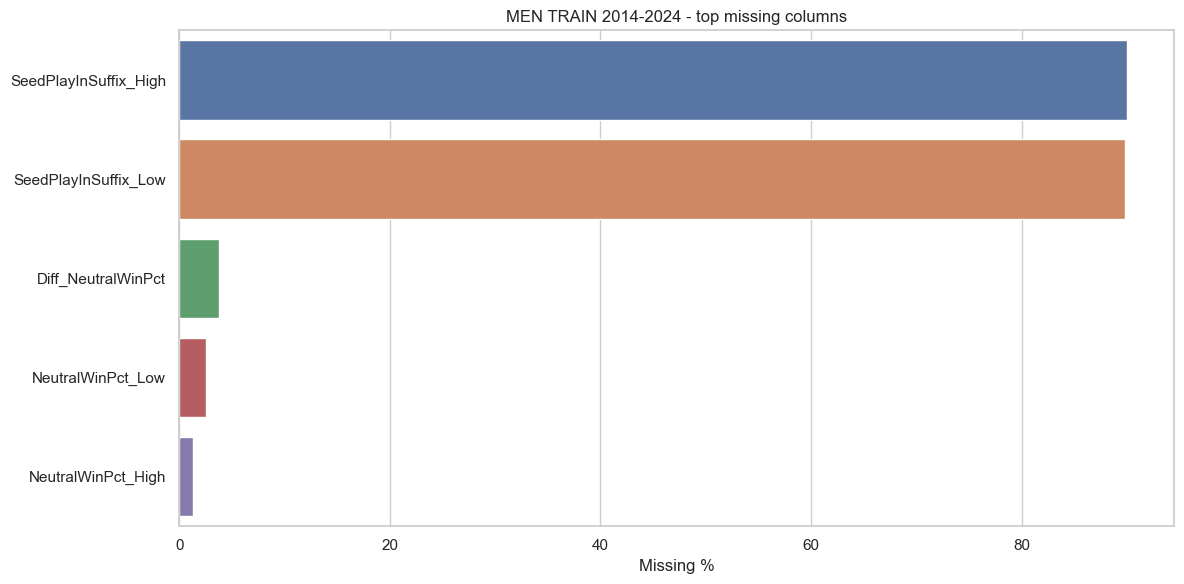


Columns with nunique <= 1:


,column,nunique_including_na
0,Sex,1
1,Diff_MasseyLastDayMax,1
2,MasseyLastDayMax_High,1
3,Same_Seed,1
4,MasseyLastDayMax_Low,1



Near-constant columns (dominant share >= 99.5%):


,column,dominant_value,dominant_share
0,Sex,M,1.000000
2,MasseyLastDayMax_Low,133,1.000000
4,MasseyLastDayMax_High,133,1.000000
5,Diff_MasseyLastDayMax,0,1.000000
6,Same_Seed,0,1.000000
1,ConfTourneyConfsPlayed_Low,1.0,0.997010
3,ConfTourneyConfsPlayed_High,1.0,0.995516



Top abs correlations with Target (all numeric):


,column,corr_with_target,abs_corr
0,Diff_MasseyRankStd,-0.445157,0.445157
1,Diff_SeedNum,-0.444752,0.444752
2,Diff_MasseyRankWorst,-0.431622,0.431622
3,Diff_MasseyRankMean,-0.423979,0.423979
4,Diff_MasseyRankMedian,-0.423822,0.423822
5,Diff_MasseySystemsCount,0.419670,0.419670
6,Diff_MasseyRankBest,-0.376480,0.376480
7,SeedNum_Low,-0.372651,0.372651
8,Diff_MasseyRankBestInv,0.372370,0.372370
9,Diff_MarginAvg,0.361725,0.361725



Top abs correlations with Target (Diff_* only):


,column,corr_with_target,abs_corr
0,Diff_MasseyRankStd,-0.445157,0.445157
1,Diff_SeedNum,-0.444752,0.444752
2,Diff_MasseyRankWorst,-0.431622,0.431622
3,Diff_MasseyRankMean,-0.423979,0.423979
4,Diff_MasseyRankMedian,-0.423822,0.423822
5,Diff_MasseySystemsCount,0.419670,0.419670
6,Diff_MasseyRankBest,-0.376480,0.376480
7,Diff_MasseyRankBestInv,0.372370,0.372370
8,Diff_MarginAvg,0.361725,0.361725
9,Diff_NetRtgAvg,0.359745,0.359745


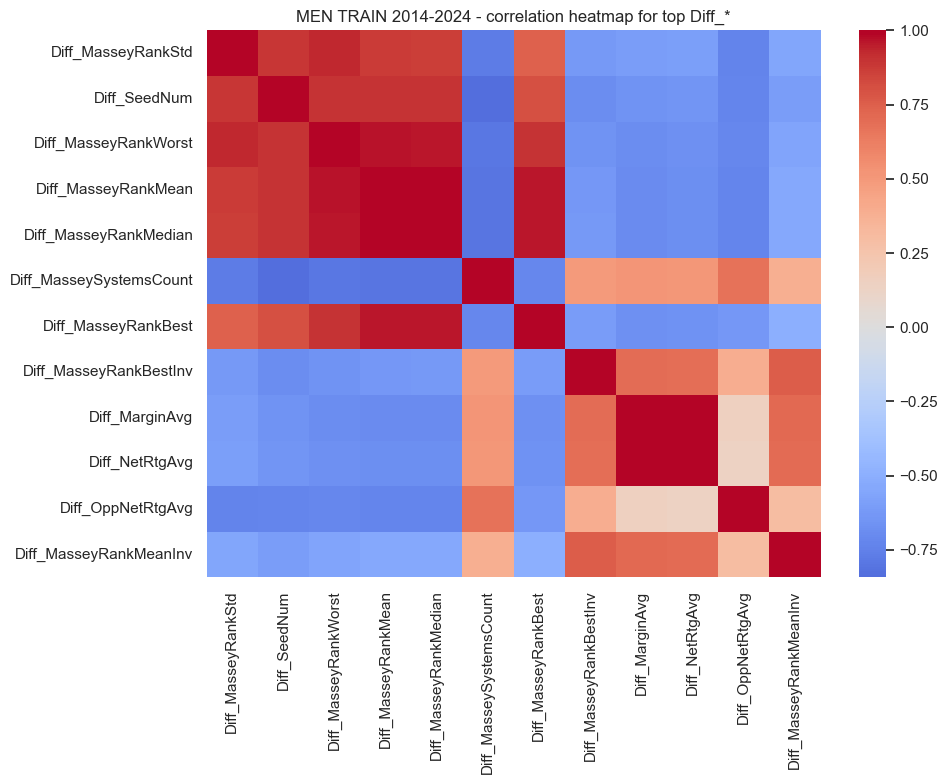


Top features selected for plots:
['Diff_MasseyRankStd', 'Diff_SeedNum', 'Diff_MasseyRankWorst', 'Diff_MasseyRankMean', 'Diff_MasseyRankMedian', 'Diff_MasseySystemsCount', 'Diff_MasseyRankBest', 'Diff_MasseyRankBestInv']


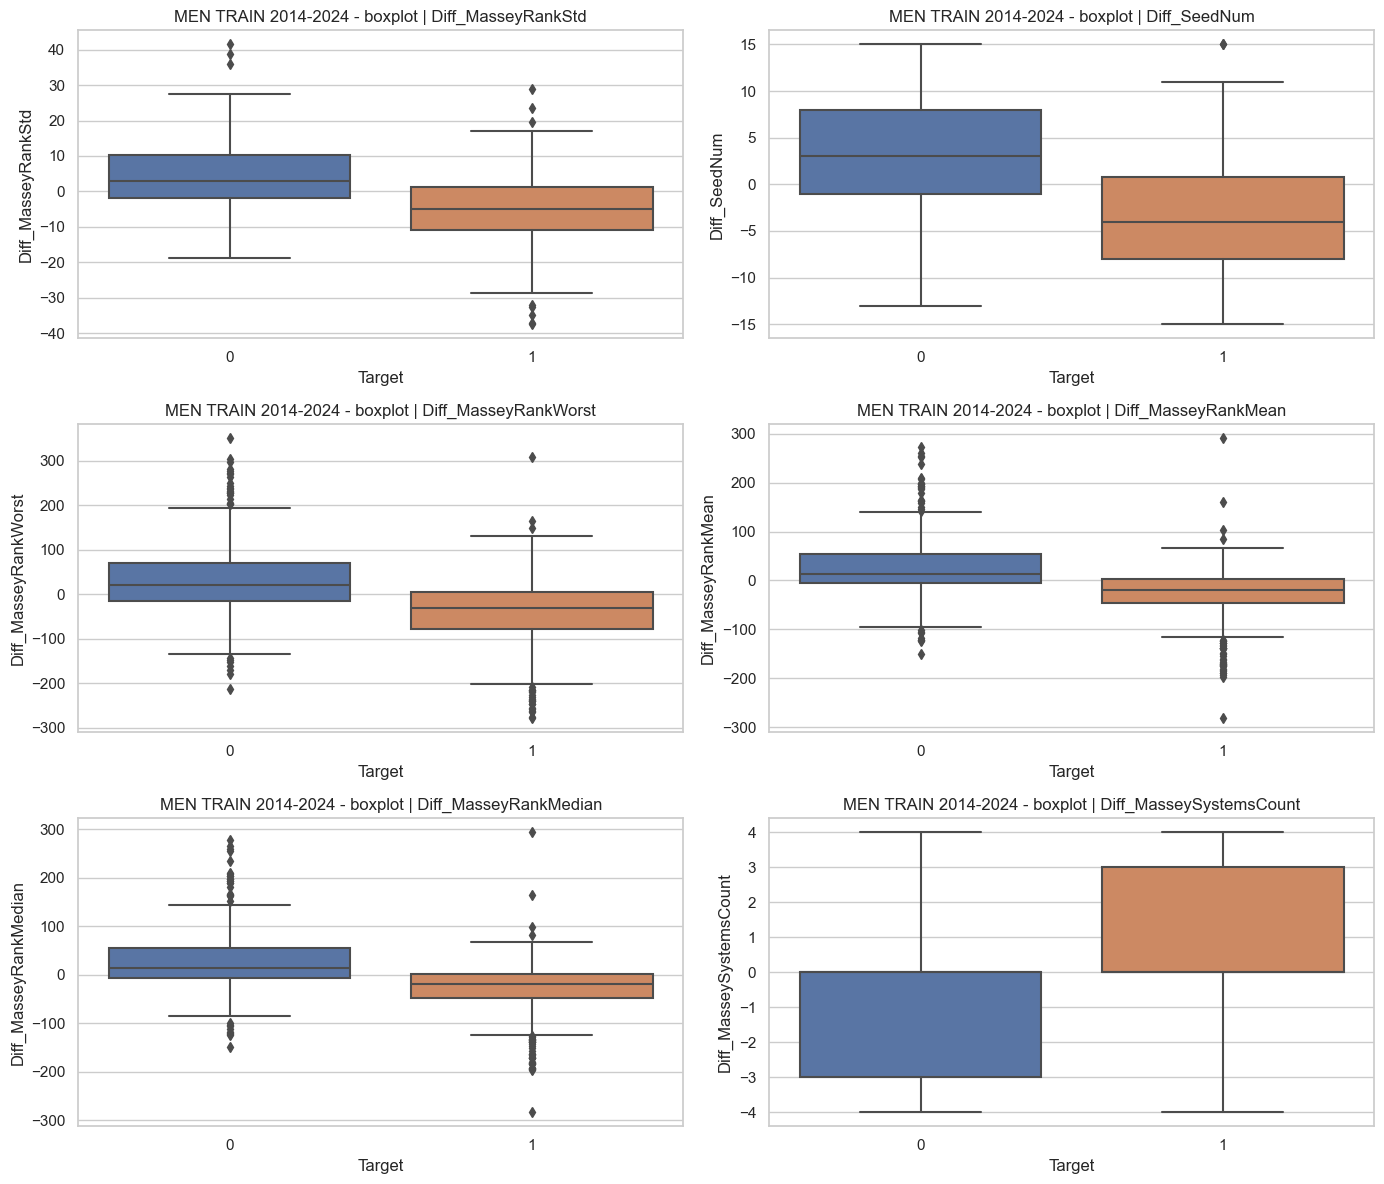

c:\Users\66891\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\66891\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
c:\Users\66891\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
c:\Users\66891\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1075: FutureWarning: When grouping with a len

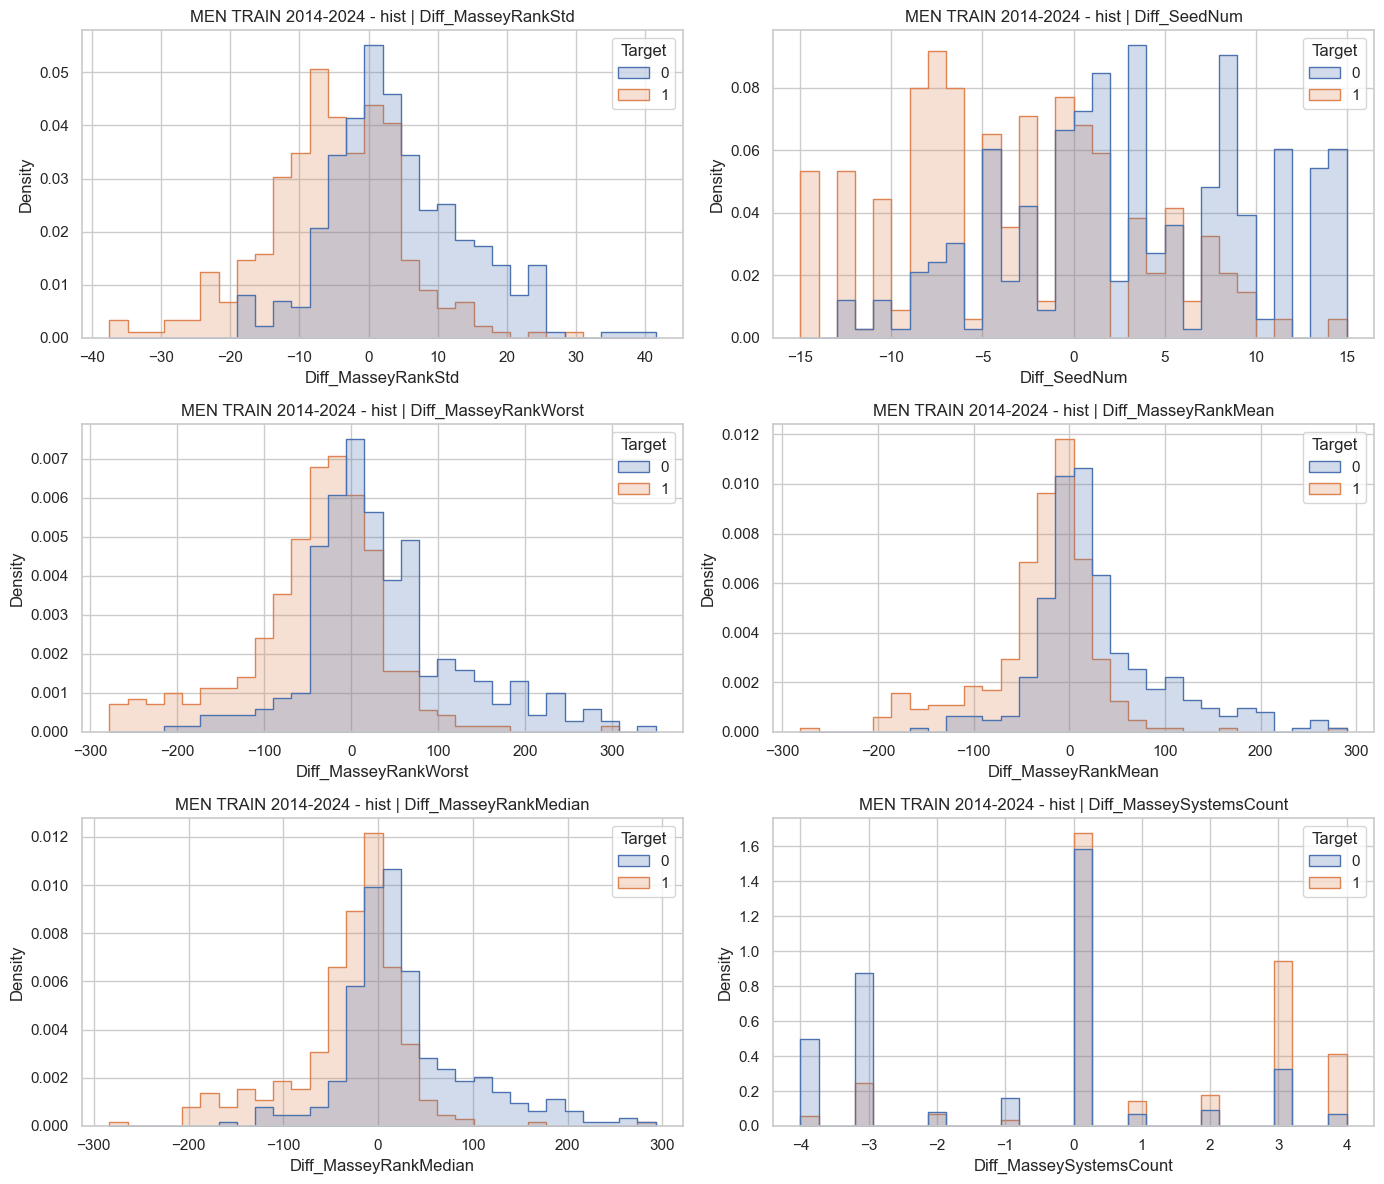


WOMEN TRAIN 2014-2024
shape: (642, 237)
target mean: 0.48753894080996885
target counts:
Target
0    329
1    313
Name: count, dtype: int64

unique seasons: [2014, 2015, 2016, 2017, 2018, 2019, 2021, 2022, 2023, 2024]
total missing cells: 1321

Top missing columns:


,column,missing_count,missing_pct
0,SeedPlayInSuffix_High,626,97.507788
1,SeedPlayInSuffix_Low,621,96.728972
2,Diff_NeutralWinPct,37,5.763240
3,NeutralWinPct_High,20,3.115265
4,NeutralWinPct_Low,17,2.647975


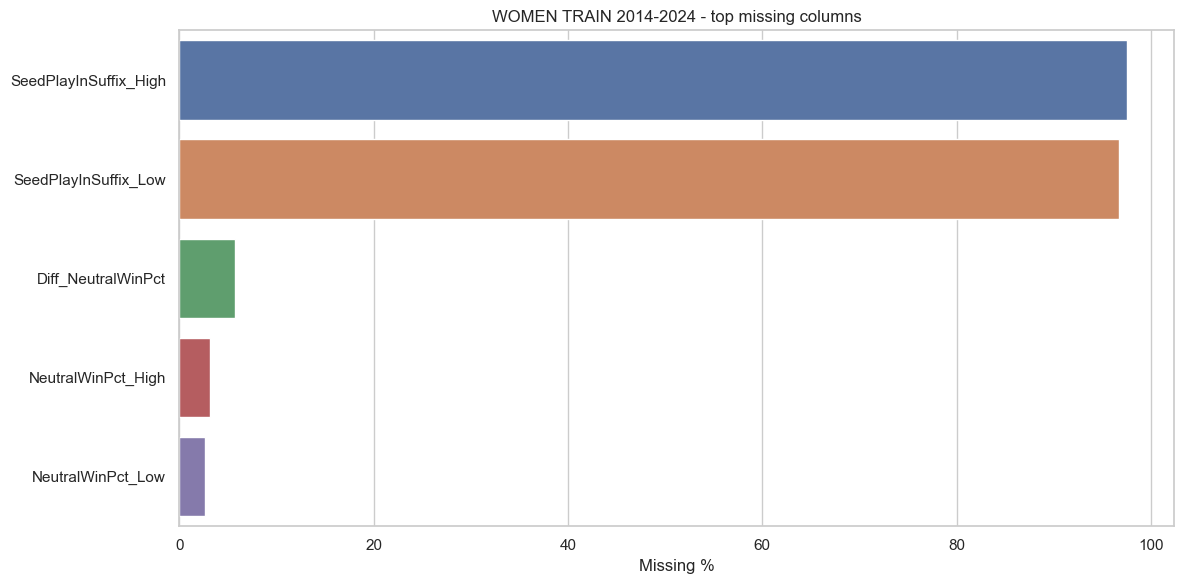


Columns with nunique <= 1:


,column,nunique_including_na
0,Sex,1
1,Same_Seed,1



Near-constant columns (dominant share >= 99.5%):


,column,dominant_value,dominant_share
0,Sex,W,1.000000
2,Same_Seed,0,1.000000
1,ConfTourneyConfsPlayed_High,1.0,0.998442



Top abs correlations with Target (all numeric):


,column,corr_with_target,abs_corr
0,Diff_SeedNum,-0.617705,0.617705
1,SeedNum_Low,-0.516691,0.516691
2,Diff_OppWinPctAvg,0.491208,0.491208
3,Diff_OppNetRtgAvg,0.483476,0.483476
4,Diff_MarginAvg,0.482175,0.482175
5,SeedNum_High,0.472575,0.472575
6,Diff_AvgFGM,0.470713,0.470713
7,Diff_NetRtgAvg,0.469044,0.469044
8,Diff_OffRtgAvg,0.441565,0.441565
9,Diff_PtsForAvg,0.428941,0.428941



Top abs correlations with Target (Diff_* only):


,column,corr_with_target,abs_corr
0,Diff_SeedNum,-0.617705,0.617705
1,Diff_OppWinPctAvg,0.491208,0.491208
2,Diff_OppNetRtgAvg,0.483476,0.483476
3,Diff_MarginAvg,0.482175,0.482175
4,Diff_AvgFGM,0.470713,0.470713
5,Diff_NetRtgAvg,0.469044,0.469044
6,Diff_OffRtgAvg,0.441565,0.441565
7,Diff_PtsForAvg,0.428941,0.428941
8,Diff_OppOffRtgAvg,0.425408,0.425408
9,Diff_Wins,0.395827,0.395827


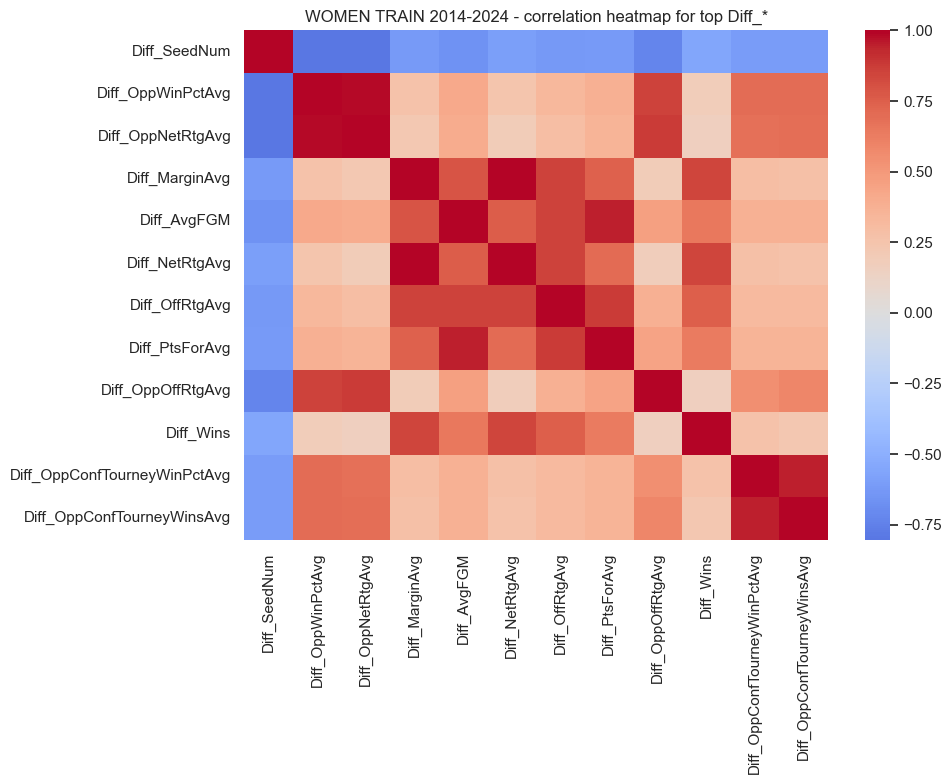


Top features selected for plots:
['Diff_SeedNum', 'Diff_OppWinPctAvg', 'Diff_OppNetRtgAvg', 'Diff_MarginAvg', 'Diff_AvgFGM', 'Diff_NetRtgAvg', 'Diff_OffRtgAvg', 'Diff_PtsForAvg']


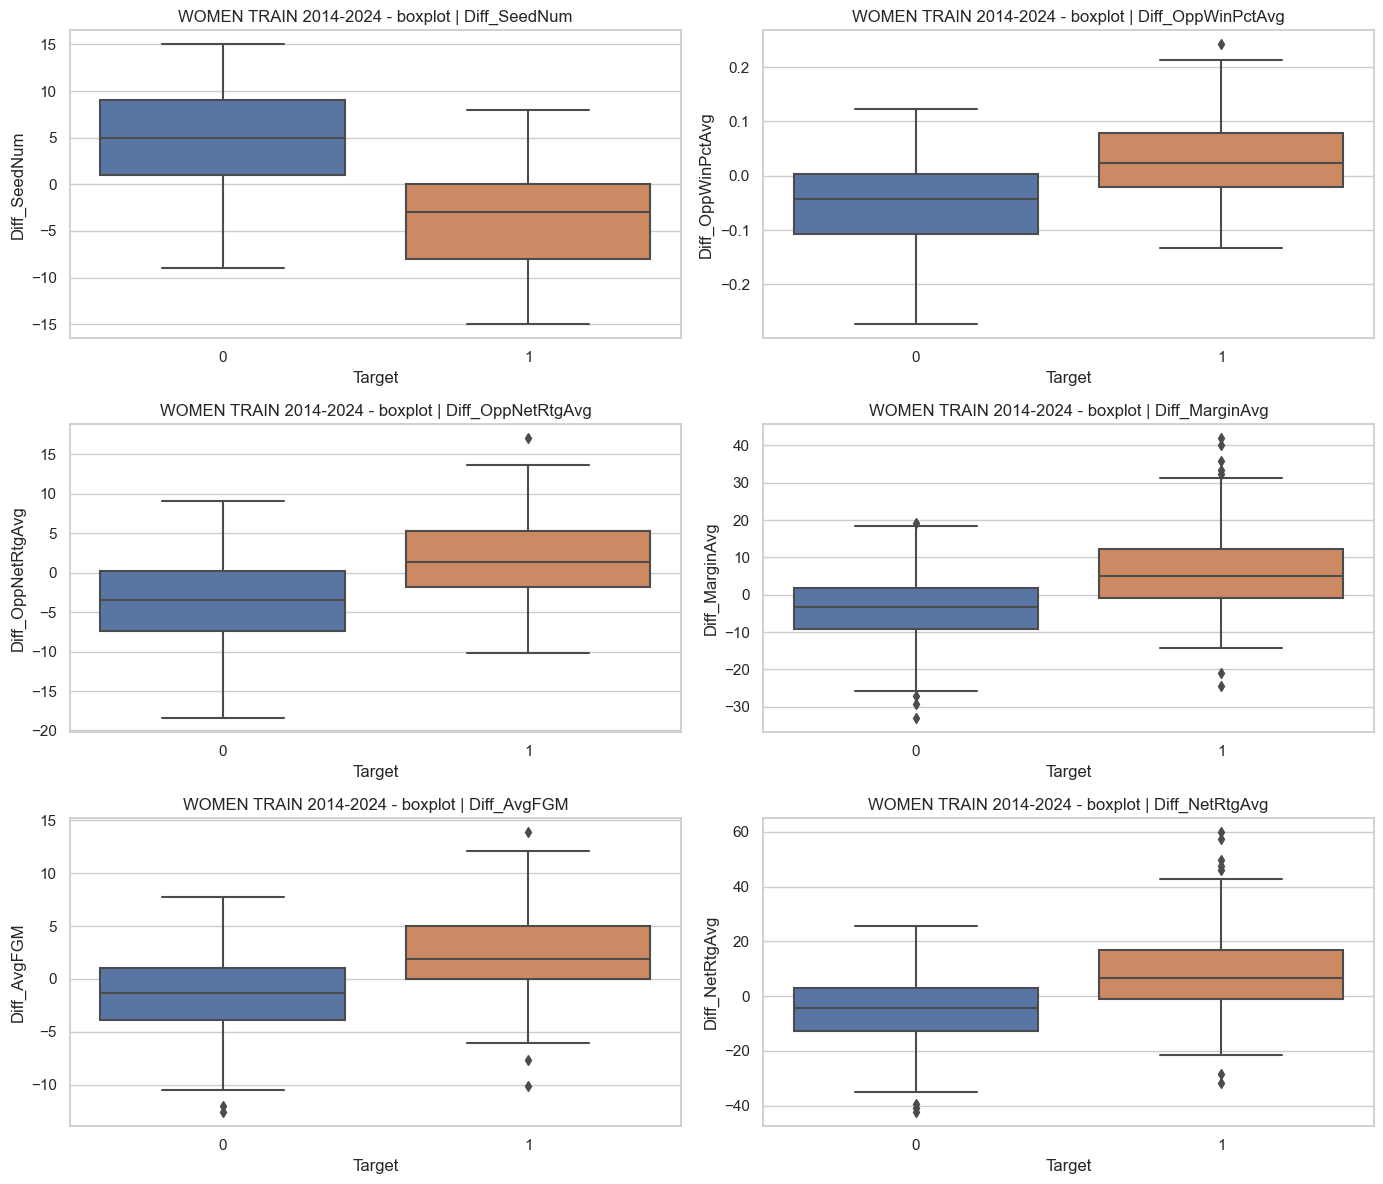

c:\Users\66891\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\66891\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
c:\Users\66891\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
c:\Users\66891\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1075: FutureWarning: When grouping with a len

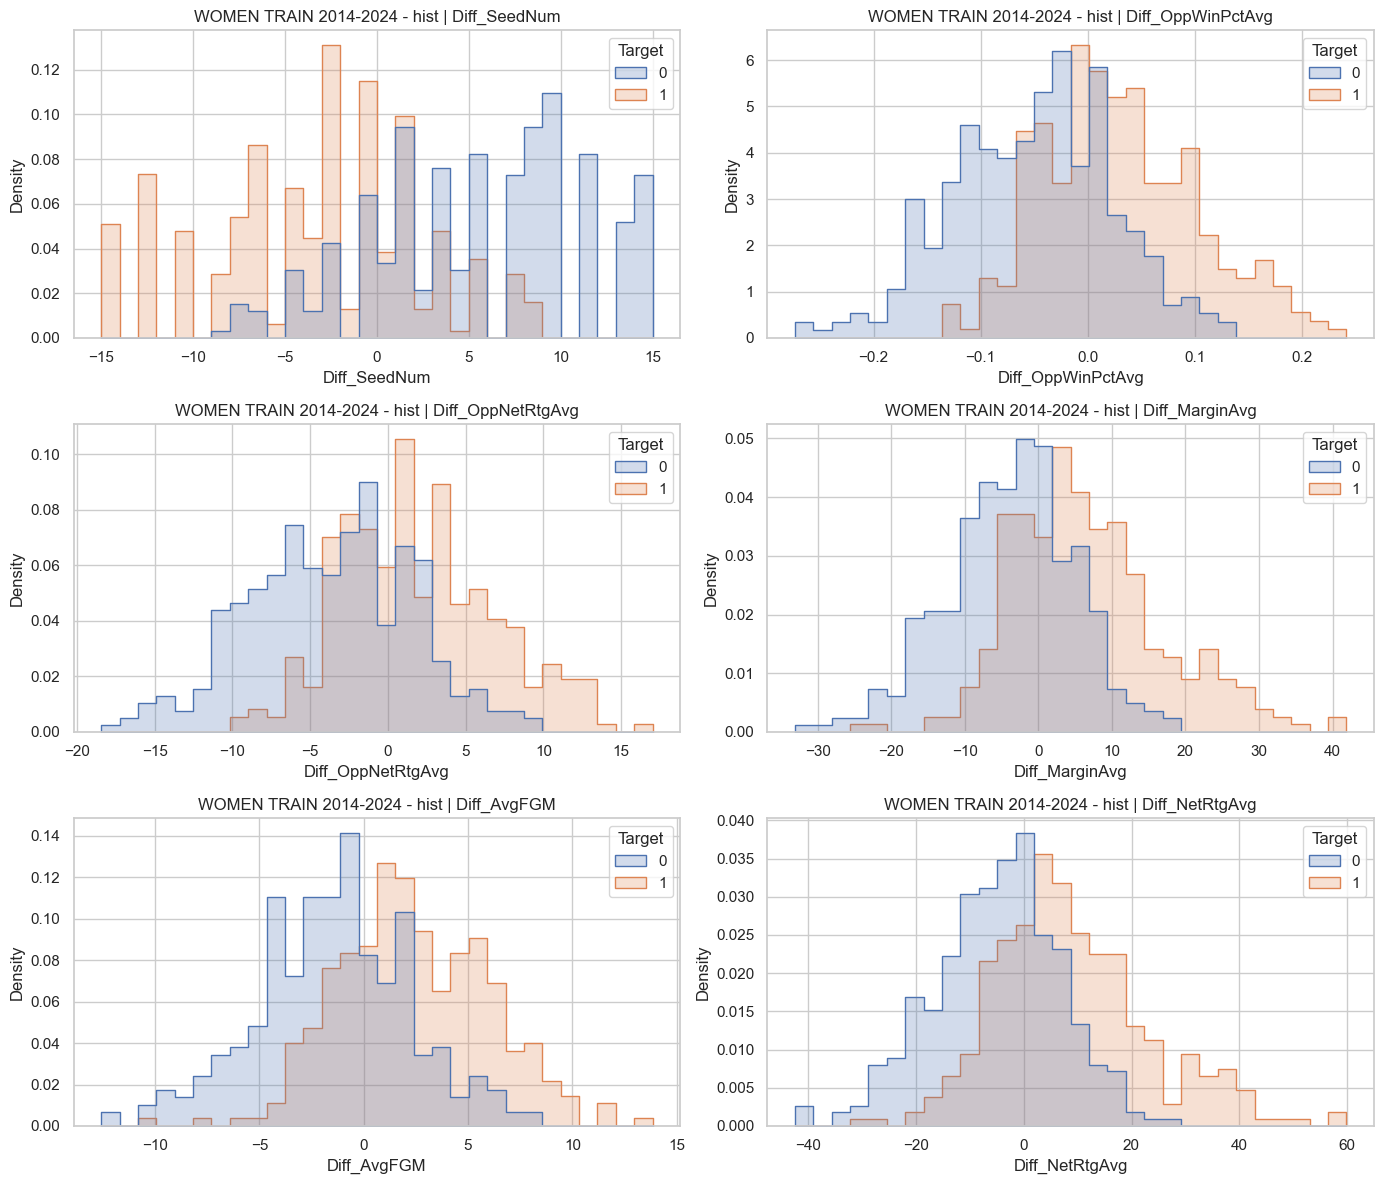

In [6]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# =========================================================
# 0. USTAWIENIA
# =========================================================
DATA_DIR = Path("data")
OUT_DIR = DATA_DIR / "interim"

# Używamy TRAIN, bo ma dużo więcej rekordów niż sam valid 2025
m_df = pd.read_csv(OUT_DIR / "m_matchups_train_2014_2024.csv")
w_df = pd.read_csv(OUT_DIR / "w_matchups_train_2014_2024.csv")

sns.set_theme(style="whitegrid")

# =========================================================
# 1. FUNKCJE POMOCNICZE
# =========================================================
def summarize_dataset(df: pd.DataFrame, name: str):
    print(f"\n{'='*70}")
    print(f"{name}")
    print(f"{'='*70}")
    print("shape:", df.shape)
    print("target mean:", df["Target"].mean())
    print("target counts:")
    print(df["Target"].value_counts(dropna=False).sort_index())
    print("\nunique seasons:", sorted(df["Season"].unique().tolist()))
    print("total missing cells:", int(df.isna().sum().sum()))

def get_missing_summary(df: pd.DataFrame, top_n: int = 20) -> pd.DataFrame:
    miss = df.isna().sum().sort_values(ascending=False)
    miss = miss[miss > 0]
    out = pd.DataFrame({
        "column": miss.index,
        "missing_count": miss.values,
        "missing_pct": (miss.values / len(df)) * 100
    })
    return out.head(top_n)

def get_constant_summary(df: pd.DataFrame) -> pd.DataFrame:
    nunique = df.nunique(dropna=False).sort_values()
    out = pd.DataFrame({
        "column": nunique.index,
        "nunique_including_na": nunique.values
    })
    return out

def get_near_constant_columns(df: pd.DataFrame, threshold: float = 0.995):
    cols = []
    for c in df.columns:
        vc = df[c].value_counts(dropna=False, normalize=True)
        if len(vc) > 0 and vc.iloc[0] >= threshold:
            cols.append((c, vc.index[0], vc.iloc[0]))
    return pd.DataFrame(cols, columns=["column", "dominant_value", "dominant_share"]).sort_values(
        "dominant_share", ascending=False
    )

def top_abs_correlations_with_target(df: pd.DataFrame, top_n: int = 20, diff_only: bool = False) -> pd.DataFrame:
    numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
    numeric_cols = [c for c in numeric_cols if c != "Target"]

    if diff_only:
        numeric_cols = [c for c in numeric_cols if c.startswith("Diff_")]

    corrs = []
    for c in numeric_cols:
        s = df[c]
        if s.notna().sum() < 10:
            continue
        if s.nunique(dropna=True) <= 1:
            continue
        corr = s.corr(df["Target"])
        if pd.notna(corr):
            corrs.append((c, corr, abs(corr)))

    out = pd.DataFrame(corrs, columns=["column", "corr_with_target", "abs_corr"])
    out = out.sort_values("abs_corr", ascending=False).reset_index(drop=True)
    return out.head(top_n)

def plot_missing_bar(miss_df: pd.DataFrame, title: str):
    if miss_df.empty:
        print(f"\n{title}: brak missing values.")
        return

    plt.figure(figsize=(12, 6))
    sns.barplot(data=miss_df, x="missing_pct", y="column")
    plt.title(title)
    plt.xlabel("Missing %")
    plt.ylabel("")
    plt.tight_layout()
    plt.show()

def plot_corr_heatmap(df: pd.DataFrame, corr_df: pd.DataFrame, title: str, top_n: int = 12):
    cols = corr_df["column"].head(top_n).tolist()
    if len(cols) < 2:
        print(f"\n{title}: za mało kolumn do heatmapy.")
        return

    corr_mat = df[cols].corr()

    plt.figure(figsize=(10, 8))
    sns.heatmap(corr_mat, annot=False, cmap="coolwarm", center=0)
    plt.title(title)
    plt.tight_layout()
    plt.show()

def plot_boxplots_by_target(df: pd.DataFrame, feature_list, title_prefix: str):
    feature_list = [c for c in feature_list if c in df.columns]
    if not feature_list:
        return

    n = len(feature_list)
    rows = int(np.ceil(n / 2))
    fig, axes = plt.subplots(rows, 2, figsize=(14, 4 * rows))
    axes = np.array(axes).reshape(-1)

    for ax, col in zip(axes, feature_list):
        sns.boxplot(data=df, x="Target", y=col, ax=ax)
        ax.set_title(f"{title_prefix} | {col}")

    for ax in axes[n:]:
        ax.axis("off")

    plt.tight_layout()
    plt.show()

def plot_histograms_by_target(df: pd.DataFrame, feature_list, title_prefix: str):
    feature_list = [c for c in feature_list if c in df.columns]
    if not feature_list:
        return

    n = len(feature_list)
    rows = int(np.ceil(n / 2))
    fig, axes = plt.subplots(rows, 2, figsize=(14, 4 * rows))
    axes = np.array(axes).reshape(-1)

    for ax, col in zip(axes, feature_list):
        sns.histplot(data=df, x=col, hue="Target", bins=30, stat="density",
                     common_norm=False, element="step", ax=ax)
        ax.set_title(f"{title_prefix} | {col}")

    for ax in axes[n:]:
        ax.axis("off")

    plt.tight_layout()
    plt.show()

def run_eda(df: pd.DataFrame, name: str):
    summarize_dataset(df, name)

    # missing values
    miss_df = get_missing_summary(df, top_n=20)
    print("\nTop missing columns:")
    display(miss_df)
    plot_missing_bar(miss_df, f"{name} - top missing columns")

    # constant / near-constant
    const_df = get_constant_summary(df)
    print("\nColumns with nunique <= 1:")
    display(const_df[const_df["nunique_including_na"] <= 1].head(30))

    near_const_df = get_near_constant_columns(df, threshold=0.995)
    print("\nNear-constant columns (dominant share >= 99.5%):")
    display(near_const_df.head(30))

    # correlations
    top_corr_all = top_abs_correlations_with_target(df, top_n=20, diff_only=False)
    top_corr_diff = top_abs_correlations_with_target(df, top_n=20, diff_only=True)

    print("\nTop abs correlations with Target (all numeric):")
    display(top_corr_all)

    print("\nTop abs correlations with Target (Diff_* only):")
    display(top_corr_diff)

    # heatmap top diff features
    plot_corr_heatmap(df, top_corr_diff, f"{name} - correlation heatmap for top Diff_*", top_n=12)

    # wykresy dla top cech
    top_features_for_plots = top_corr_diff["column"].head(8).tolist()
    if len(top_features_for_plots) < 4:
        top_features_for_plots = top_corr_all["column"].head(8).tolist()

    print("\nTop features selected for plots:")
    print(top_features_for_plots)

    plot_boxplots_by_target(df, top_features_for_plots[:6], f"{name} - boxplot")
    plot_histograms_by_target(df, top_features_for_plots[:6], f"{name} - hist")

# =========================================================
# 2. EDA DLA M I W
# =========================================================
run_eda(m_df, "MEN TRAIN 2014-2024")
run_eda(w_df, "WOMEN TRAIN 2014-2024")